# CNN → DNN: ENFORCE + Evolutionary NAS (PyTorch)

**Pipeline:**
```
Teacher CNN (frozen)
  └─ ENFORCE LogitRefiner  (dual-head autoencoder on teacher logits; normalized latent = hint target)
       └─ Stage 1: HSR hint distillation  (Bridge learns from refined latent)
            └─ Stage 2: DKD fine-tuning   (Bridge, relaxation layers + head only)
                 └─ 1M anchor student     (CompressedHSRBridge, full KD from Bridge)
                      └─ Evolutionary NAS (tournament + mutation + crossover; warm-start from 1M)
                           └─ Winner fine-tuned per budget
                                └─ Benchmark
```

Design decisions:
- **ENFORCE LogitRefiner** stabilises teacher logits before distillation (dual-head: reconstruction-dominant, classification-regularised).
- **1M anchor** provides a warm-start weight pool for NAS candidates — smaller budgets inherit weights via slicing, not cold-start.
- **Evolutionary search** uses tournament selection, mutation (per-gene probability), and crossover to explore the architecture space within each parameter budget.


## 0. Imports and device

In [1]:
import os, gc, copy, random, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
torch.backends.cudnn.enabled=False

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Configuration

In [66]:
from pathlib import Path
BASE_DIR=Path.cwd().parent

CONFIG = {
    # Data
    "seed"           : SEED,
    "input_shape"    : (40, 40, 1),
    "pixel_dim"      : 1600,
    "tracker_dim"    : 25,
    "num_classes"    : 12,
    "batch_size"     : 32,
    "dataset_path"   : BASE_DIR / "data" /"dataset_kws_multi.npz",

    # ENFORCE LogitRefiner
    "refiner_epochs" : 25,
    "refiner_lr"     : 1e-3,
    "refiner_lambda_cls": 0.1,   # reconstruction-dominant; cls regularises latent

    # Stage 1 — HSR hint distillation
    "stage1_epochs"  : 300,
    "stage1_lr"      : 2e-4,
    "hint_weight"    : 0.3,
    "ce_weight"      : 1.0,

    # Stage 2 — DKD fine-tuning
    "stage2_epochs"  : 150,
    "stage2_lr"      : 1e-5,
    "kd_temperature" : 4.0,
    "dkd_alpha"      : 1.0,
    "dkd_beta"       : 1.0,
    "dkd_weight"     : 0.05,
    "nuc_weight"     : 1e-4,

    # 1M anchor student (warm-start for NAS)
    "anchor_budget"  : 1_000_000,
    "anchor_epochs"  : 200,
    "anchor_lr"      : 2e-4,
    "anchor_weights" : BASE_DIR / "models" / "anchor_1M.pth",

    # Evolutionary NAS
    "nas_budgets"    : [589_000], #[200_000, 350_000, 589_000],
    "nas_generations": 5, #50,
    "nas_pop_size"   : 4, #24,
    "nas_tourn_k"    : 2, #4,
    "nas_mut_prob"   : 0.3,
    "nas_proxy_ep"   : 5, #20,       # proxy epochs during evolution (val ranking)
    "nas_proxy_lr"   : 5e-4,
    "nas_finetune_ep": 2, #100,      # full fine-tune of winner from 1M weights
    "nas_finetune_lr": 1e-4,
    "nas_patience"   : 2, #10,

    # NAS search space
    "rank_choices"   : [4, 8, 16, 32],
    "fusion_choices" : [32, 64, 96, 128],
    "embed_choices"  : [16, 32, 48, 64],

    # Shared
    "weight_decay"   : 5e-4,
    "patience"       : 20,
    "focal_gamma"    : 2.0,
    "mixup_alpha"    : 0.2,
    "mixup_prob"     : 0.4,

    # File paths
    "teacher_weights"      : BASE_DIR / "models" /"kws_multi_cnn_model_pytorch.pth",
    "bridge_stage1_weights": BASE_DIR / "models" /"bridge_stage1.pth",
    "bridge_stage2_weights": BASE_DIR / "models" /"bridge_stage2.pth",
    "nas_results_path"     : BASE_DIR / "models" /"nas_results.json",
    "nas_subnet_prefix"    : BASE_DIR /"models" /"nas_bridge",
}
CONFIG["flat_dim"] = CONFIG["pixel_dim"] + CONFIG["tracker_dim"]
print("CONFIG ready — flat_dim =", CONFIG["flat_dim"])


CONFIG ready — flat_dim = 1625


## 2. Dataset

In [24]:
def create_dataset(shape_input, file, values_name, labels_name, threshold=-1, percentage=1.0):
    H, W = shape_input[:2]; C = shape_input[2] if len(shape_input)==3 else 1
    ds = np.load(file, allow_pickle=True)
    samples = ds[values_name][:, :H, :W]
    classes = ds[labels_name].astype(int)
    label_map_dict=ds["label_map"].item()
    unknown_original_idx=label_map_dict["unknown"]
    known_mask=classes!=unknown_original_idx
    unk_mask=~known_mask
    X_known, y_known=samples[known_mask], classes[known_mask]
    X_unk, y_unk=samples[unk_mask], classes[unk_mask]
    orig_known_indices=sorted(np.unique(y_known).tolist())
    orig_to_new={orig: new for new, orig in enumerate(orig_known_indices)}
    unknown_new_idx=len(orig_known_indices)
    orig_to_new[unknown_original_idx]=unknown_new_idx
    y_known_new=np.array([orig_to_new[c] for c in y_known])
    y_unk_remapped=np.full(len(y_unk), unknown_new_idx, dtype=int)

    Xtr,Xtmp,ytr,ytmp=train_test_split(X_known,y_known_new,test_size=0.3,random_state=SEED)
    Xva_k,Xte_k,yva_k,yte_k=train_test_split(Xtmp,ytmp,test_size=0.5,random_state=SEED)
    Xva_u,Xte_u,yva_u,yte_u=train_test_split(X_unk, y_unk_remapped, test_size=0.5, random_state=SEED)
    Xva=np.concatenate([Xva_k, Xva_u])
    yva=np.concatenate([yva_k, yva_u])
    Xte=np.concatenate([Xte_k, Xte_u])
    yte=np.concatenate([yte_k, yte_u])
    
    for X, y in [(Xva, yva), (Xte, yte)]:
        perm=np.random.permutation(len(y))
        X[:], y[:]=X[perm], y[perm]
    
    if percentage<1.0:
        ks,ky=[],[]
        for cls in np.unique(ytr):
            idx=np.where(ytr==cls)[0]; n=max(1,int(len(idx)*percentage))
            sel=np.random.choice(idx,size=n,replace=False); ks.append(Xtr[sel]); ky.append(ytr[sel])
        Xtr,ytr=np.concatenate(ks),np.concatenate(ky)
    
    def add_ch(x): 
        return np.expand_dims(x,-1) if x.ndim==3 else x
    
    Xtr,Xva,Xte=add_ch(Xtr),add_ch(Xva),add_ch(Xte)
    n_cls=unknown_new_idx+1
    assert (ytr==unknown_new_idx).sum()==0, "Unknows leaked into training!"
    assert (yva==unknown_new_idx).sum()>0, "No unknowns in VAL!"
    assert (yte==unknown_new_idx).sum()>0, "No unknowns in test!"
    
    print(f"Train {Xtr.shape}  Val {Xva.shape}  Test {Xte.shape}  n_classes={n_cls}")
    print(f"Train unknowns: {(ytr==unknown_new_idx).sum()}")
    print(f"Val unknowns: {(yva==unknown_new_idx).sum()}")
    print(f"Test unknows: {(yte==unknown_new_idx).sum()}")
    return Xtr, ytr, Xva, yva, Xte, yte, n_cls, orig_to_new

shape_input=(40,40,1)
X_train_np, y_train_np, X_val_np, y_val_np, X_test_np, y_test_np, n_classes, orig_to_new=create_dataset(shape_input, CONFIG["dataset_path"], "features", "labels")

dataset_archive=np.load(CONFIG["dataset_path"], allow_pickle=True)
label_map_dict=dataset_archive['label_map'].item()
new_to_name={orig_to_new[v]: k for k, v in label_map_dict.items()}
class_names=[new_to_name[i] for i in range(n_classes)]
unknown_idx=orig_to_new[label_map_dict["unknown"]]
known_indices=[i for i in range(n_classes) if i!=unknown_idx]
CONFIG["num_classes"]=n_classes

print(f"\nClass Names ({n_classes}): {class_names}")
print(f"unknown_idx={unknown_idx}, known_indices={known_indices}")
CONFIG["num_classes"]=len(class_names)

new_to_orig={v: k for k, v in orig_to_new.items()}
teacher_col_order=torch.tensor([new_to_orig[i] for i in range(n_classes)], dtype=torch.long, device=device)
print(f"\nteacher_col_order: {teacher_col_order.tolist()}")
print("(apply as: teacher_logits[:, teacher_col_order])")

X_train=torch.FloatTensor(X_train_np).permute(0, 3, 1, 2)
X_val=torch.FloatTensor(X_val_np).permute(0, 3, 1, 2)
X_test=torch.FloatTensor(X_test_np).permute(0, 3, 1, 2)
y_train=torch.LongTensor(y_train_np)
y_val=torch.LongTensor(y_val_np)
y_test=torch.LongTensor(y_test_np)
print(f"\nPyTorch Tensors Ready (NCHW): {X_train.shape}")

train_dataset=TensorDataset(X_train, y_train)
val_dataset=TensorDataset(X_val, y_val)
test_dataset=TensorDataset(X_test, y_test)
train_loader=DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

Train (29589, 40, 40, 1)  Val (7962, 40, 40, 1)  Test (7963, 40, 40, 1)  n_classes=12
Train unknowns: 0
Val unknowns: 1622
Test unknows: 1622

Class Names (12): ['right', 'off', 'down', 'yes', 'no', 'stop', 'left', 'go', 'up', 'on', 'silence', 'unknown']
unknown_idx=11, known_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

teacher_col_order: [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 5]
(apply as: teacher_logits[:, teacher_col_order])

PyTorch Tensors Ready (NCHW): torch.Size([29589, 1, 40, 40])


In [25]:
from sklearn.preprocessing import StandardScaler

def to_spatial(X): return torch.FloatTensor(X).permute(0,3,1,2)
def to_flat(X):    return torch.FloatTensor(X.reshape(len(X),-1))

X_train_spatial=X_train
X_val_spatial=X_val
X_test_spatial=X_test

y_train_t=y_train 
y_val_t=y_val
y_test_t=y_test

X_tr_np=X_train.cpu().numpy().transpose(0,2,3,1)
X_va_np=X_val.cpu().numpy().transpose(0,2,3,1)
X_te_np=X_test.cpu().numpy().transpose(0,2,3,1)

assert X_train_spatial.shape==(len(X_train), 1, 40, 40), f"Bad spatial shape: {X_train_spatial.shape}"
assert X_tr_np.shape==(len(X_train), 40, 40, 1), f"Bad numpy shape: {X_tr_np.shape}"
print(f"X_train_spatial: {X_train_spatial.shape}")
print(f"X_tr_np: {X_tr_np.shape} (NWHC OK)")

def extract_audio_features(X_data):
    B=X_data.shape[0]; X=X_data.squeeze(-1); F_,T=X.shape[1],X.shape[2]; eps=1e-8
    feats=[]; freq_ax=np.arange(F_)
    band_pow=X.sum(axis=2)+eps; total_band=band_pow.sum(axis=1,keepdims=True)+eps
    sc=(band_pow*freq_ax[None,:]).sum(1)/total_band.squeeze()
    sv=((freq_ax[None,:]-sc[:,None])**2*band_pow).sum(1)/total_band.squeeze()
    feats+=[sc[:,None],np.sqrt(sv)[:,None]]
    cum=np.cumsum(band_pow,axis=1)
    feats.append(np.argmax(cum>=0.85*total_band,axis=1)[:,None])
    for lo,hi in [(0,F_//3),(F_//3,2*F_//3),(2*F_//3,F_)]:
        feats.append(X[:,lo:hi,:].mean(axis=(1,2))[:,None])
    frame_pow=X.sum(axis=1)+eps
    tc=(frame_pow*np.arange(T)[None,:]).sum(1)/(frame_pow.sum(1)+eps)
    feats.append(tc[:,None])
    fd=np.diff(X,axis=1); feats.append((fd[:,:-1,:]*fd[:,1:,:]<0).mean(axis=(1,2))[:,None])
    for b in range(13):
        s,e=int(b*F_/13),int((b+1)*F_/13); feats.append(X[:,s:e,:].mean(axis=(1,2))[:,None])
    feats.append(np.maximum(0,np.diff(frame_pow,axis=1)).mean(1)[:,None])
    feats.append(frame_pow.mean(1)[:,None]); feats.append(frame_pow.std(1)[:,None])
    fv=X.var(axis=1).mean(1); tv=X.var(axis=2).mean(1)
    feats.append((tv/(fv+eps))[:,None])
    return np.concatenate(feats,axis=1).astype(np.float32)

tr_feats=extract_audio_features(X_tr_np)
va_feats=extract_audio_features(X_va_np)
te_feats=extract_audio_features(X_te_np)

scaler=StandardScaler()
tr_feats_scaled=scaler.fit_transform(tr_feats)
va_feats_scaled=scaler.transform(va_feats)
te_feats_scaled=scaler.transform(te_feats)

X_train_full=np.concatenate([X_train.numpy().reshape(len(X_train),-1),tr_feats_scaled],axis=1)
X_val_full  =np.concatenate([X_val.numpy().reshape(len(X_val),-1),  va_feats_scaled],axis=1)
X_test_full =np.concatenate([X_test.numpy().reshape(len(X_test),-1),te_feats_scaled],axis=1)

X_train_full_t=torch.FloatTensor(X_train_full)
X_val_full_t  =torch.FloatTensor(X_val_full)
X_test_full_t =torch.FloatTensor(X_test_full)
print("flat_dim:", X_train_full_t.shape[1])


X_train_spatial: torch.Size([29589, 1, 40, 40])
X_tr_np: (29589, 40, 40, 1) (NWHC OK)
flat_dim: 1625


## 3. Class weights and loaders

In [26]:
def compute_class_weights(y, num_classes):
    counts=np.bincount(y,minlength=num_classes).clip(1)
    w=len(y)/(num_classes*counts); w=w/w.sum()*counts
    w=w/w.sum()*num_classes
    return {i:float(w[i]) for i in range(num_classes)}

class_weights_dict=compute_class_weights(y_train_np,n_classes)
cw=torch.FloatTensor([class_weights_dict.get(i, 1.0) for i in range(n_classes)]).to(device)
cw[unknown_idx]=0.0
print(f"Class Weights: {cw.cpu().numpy().round(3)}")
print(f" (unknown slot at index {unknown_idx} has weight 0.0 - for ODD)")
# Stage 1 loader: (spatial, full_flat, label)
train_loader=DataLoader(TensorDataset(X_train_spatial,X_train_full_t,y_train_t), batch_size=CONFIG["batch_size"],shuffle=True,drop_last=True)
val_loader=DataLoader(TensorDataset(X_val_spatial,  X_val_full_t,  y_val_t), batch_size=CONFIG["batch_size"],shuffle=False)
test_loader=DataLoader(TensorDataset(X_test_spatial,  X_test_full_t,  y_test_t), batch_size=CONFIG["batch_size"],shuffle=False)
# NAS / evaluation loaders: (full_flat, label)
flat_train_loader=DataLoader(TensorDataset(X_train_full_t,y_train_t),batch_size=CONFIG["batch_size"],shuffle=True,drop_last=True)
flat_val_loader  =DataLoader(TensorDataset(X_val_full_t,  y_val_t),  batch_size=CONFIG["batch_size"],shuffle=False)
flat_test_loader =DataLoader(TensorDataset(X_test_full_t, y_test_t), batch_size=CONFIG["batch_size"],shuffle=False)
print("Loaders ready")


Class Weights: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]
 (unknown slot at index 11 has weight 0.0 - for ODD)
Loaders ready


## 4. Architectures

### 4.1 Teacher CNN

In [6]:
class TeacherCNN(nn.Module):
    def __init__(self, input_shape=(1,40,40), num_classes=11):
        super().__init__()
        C=input_shape[0]
        self.conv1=nn.Conv2d(C,  32,3,padding=1,bias=False); self.bn1=nn.BatchNorm2d(32)
        self.pool1=nn.MaxPool2d(2,2); self.drop1=nn.Dropout(0.2)
        self.conv2=nn.Conv2d(32, 64,3,padding=1,bias=False); self.bn2=nn.BatchNorm2d(64)
        self.pool2=nn.MaxPool2d(2,2); self.drop2=nn.Dropout(0.3)
        self.conv3=nn.Conv2d(64,128,3,padding=1,bias=False); self.bn3=nn.BatchNorm2d(128)
        self.pool3=nn.MaxPool2d(2,2); self.drop3=nn.Dropout(0.4)
        self.fc1=nn.Linear(128*5*5,256,bias=False); self.bn4=nn.BatchNorm1d(256); self.drop4=nn.Dropout(0.5)
        self.fc2=nn.Linear(256,128,bias=False);     self.bn5=nn.BatchNorm1d(128); self.drop5=nn.Dropout(0.5)
        self.fc3=nn.Linear(128, 64,bias=False);     self.bn6=nn.BatchNorm1d(64);  self.drop6=nn.Dropout(0.5)
        self.fc_out=nn.Linear(64,num_classes)
        self._hints=[None]*6

    def forward(self,x):
        x=self.drop1(self.pool1(F.relu(self.bn1(self.conv1(x))))); self._hints[0]=x.detach()
        x=self.drop2(self.pool2(F.relu(self.bn2(self.conv2(x))))); self._hints[1]=x.detach()
        x=self.drop3(self.pool3(F.relu(self.bn3(self.conv3(x))))); self._hints[2]=x.detach()
        x=x.flatten(1)
        x=self.drop4(F.relu(self.bn4(self.fc1(x)))); self._hints[3]=x.detach()
        x=self.drop5(F.relu(self.bn5(self.fc2(x)))); self._hints[4]=x.detach()
        x=self.drop6(F.relu(self.bn6(self.fc3(x)))); self._hints[5]=x.detach()
        return self.fc_out(x)

    def get_hints(self): return [h.view(h.size(0),-1) for h in self._hints]

teacher=TeacherCNN(input_shape=(1,40,40),num_classes=n_classes).to(device)
teacher.load_state_dict(torch.load(CONFIG["teacher_weights"],map_location=device))
teacher.eval()
for p in teacher.parameters(): p.requires_grad=False
print(f"Teacher: {sum(p.numel() for p in teacher.parameters()):,} params (frozen)")
vc, vt=0, 0
with torch.no_grad():
    for i in range(0, min(2000, len(X_train)), 32):
        xb=X_train[i:i+32].to(device)
        lb=y_train[i:i+32].to(device)
        out=teacher(xb)[:, teacher_col_order]
        vc+=out.argmax(1).eq(lb).sum().item()
        vt+=lb.size(0)
print(f"\nTeacher accuracy (sample): {vc/vt*100:.2f}%")
print(teacher)

Teacher: 954,732 params (frozen)

Teacher accuracy (sample): 97.87%
TeacherCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.3, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): D

### 4.2 ENFORCE LogitRefiner

In [7]:
class LogitRefiner(nn.Module):
    """
    ENFORCE Step 2: dual-head autoencoder over teacher logits.

    Reconstruction head (MSE) — preserves raw CNN knowledge; keeps the latent
    space from collapsing into a pure classifier.
    Classification head (CE, weight=lambda_cls=0.1) — clusters latent by class.

    get_refined_targets() returns L2-normalised latent used as the hint target
    in Stage 1, replacing direct teacher activation matching.
    """
    def __init__(self, num_classes, lambda_cls=0.1):
        super().__init__()
        latent=128
        self.lambda_cls=lambda_cls
        self.encoder=nn.Sequential(
            nn.Linear(num_classes, latent*2), nn.ReLU(),
            nn.Linear(latent*2,   latent),
        )
        self.recon_head=nn.Linear(latent, num_classes)
        self.cls_head  =nn.Linear(latent, num_classes)

    def forward(self, z_cnn):
        latent    =self.encoder(z_cnn)
        z_hat     =self.recon_head(latent)
        cls_logits=self.cls_head(latent)
        return latent, z_hat, cls_logits

    def refine_loss(self, z_cnn, z_hat, cls_logits, labels):
        return F.mse_loss(z_hat, z_cnn) + self.lambda_cls*F.cross_entropy(cls_logits, labels)

    @torch.no_grad()
    def get_refined_targets(self, z_cnn):
        """Normalised latent — distillation target for Stage 1."""
        latent,_,_=self.forward(z_cnn)
        return F.normalize(latent, dim=1)


def train_logit_refiner(teacher, X_train_spatial, y_train_t, num_classes, device,
                        epochs, lr, batch_size, lambda_cls):
    print("\n"+"="*60)
    print("ENFORCE — LOGIT REFINER PRE-TRAINING")
    print("="*60)
    refiner=LogitRefiner(num_classes, lambda_cls=lambda_cls).to(device)
    opt=torch.optim.Adam(refiner.parameters(), lr=lr)

    teacher.eval()
    all_logits=[]
    with torch.no_grad():
        for i in range(0,len(X_train_spatial),batch_size):
            xb=X_train_spatial[i:i+batch_size].to(device)
            all_logits.append(teacher(xb)[:, teacher_col_order.cpu()].cpu())
    z_train=torch.cat(all_logits,dim=0)

    loader=DataLoader(TensorDataset(z_train, y_train_t),batch_size=batch_size,shuffle=True)
    for epoch in range(epochs):
        refiner.train(); ep_loss=0.
        for z_cnn,labels in loader:
            z_cnn,labels=z_cnn.to(device),labels.to(device)
            opt.zero_grad()
            latent,z_hat,cls_logits=refiner(z_cnn)
            loss=refiner.refine_loss(z_cnn,z_hat,cls_logits,labels)
            loss.backward(); opt.step(); ep_loss+=loss.item()
        if (epoch+1)%5==0 or epoch==0:
            print(f"  Ep {epoch+1:3d}/{epochs}  loss={ep_loss/len(loader):.4f}")
    refiner.eval()
    print("  Refiner training complete.")
    return refiner


@torch.no_grad()
def extract_refined_targets(teacher, refiner, X_spatial, device, batch_size=128):
    """Extract refined latent targets for any data split."""
    teacher.eval(); refiner.eval(); refined=[]
    for i in range(0,len(X_spatial),batch_size):
        xb=X_spatial[i:i+batch_size].to(device)
        logits=teacher(xb)[:, teacher_col_order]
        refined.append(refiner.get_refined_targets(logits).cpu())
    return torch.cat(refined,dim=0)

print("LogitRefiner ready")


LogitRefiner ready


### 4.3 HSRBridge

In [8]:
class HSRLayer(nn.Module):
    """Frozen conv prior + trainable low-rank correction (V_r, U_r)."""
    def __init__(self, teacher_conv, input_chw, rank=16):
        super().__init__()
        self.in_c,self.h,self.w=input_chw; self.out_c=teacher_conv.out_channels
        k,s,p=teacher_conv.kernel_size[0],teacher_conv.stride,teacher_conv.padding
        self.conv_prior=nn.Conv2d(self.in_c,self.out_c,k,stride=s,padding=p,
                                  bias=(teacher_conv.bias is not None))
        with torch.no_grad():
            self.conv_prior.weight.copy_(teacher_conv.weight)
            if teacher_conv.bias is not None: self.conv_prior.bias.copy_(teacher_conv.bias)
        for p_ in self.conv_prior.parameters(): p_.requires_grad=False
        flat_in=self.in_c*self.h*self.w 
        with torch.no_grad():
            dummy=torch.zeros(1, self.in_c, self.h, self.w)
            out_spatial=self.conv_prior(dummy)
            self.out_h, self.out_w=out_spatial.size(2), out_spatial.size(3)
        flat_out=self.out_c*self.h*self.w
        self.V_r=nn.Linear(flat_in,rank,bias=False)
        self.U_r=nn.Linear(rank,flat_out,bias=False)
        nn.init.zeros_(self.U_r.weight)

    def forward(self,x):
        prior_out=self.conv_prior(x)
        lr_out=self.U_r(self.V_r(x.flatten(1)))
        lr_out=lr_out.view(x.size(0), self.out_c, self.out_h, self.out_w)
        return prior_out+lr_out

class HSRBridge(nn.Module):
    def __init__(self, teacher, input_shape=(1,40,40), tracker_dim=33,
                 embed_dim=128, ranks=(16,8,4), dropout=0.4):
        super().__init__()
        self.pixel_dim=input_shape[0]*input_shape[1]*input_shape[2]
        self.tracker_dim=tracker_dim
        self.stage1=HSRLayer(teacher.conv1,(1, 40,40),rank=ranks[0])
        self.stage2=HSRLayer(teacher.conv2,(32,20,20),rank=ranks[1])
        self.stage3=HSRLayer(teacher.conv3,(64,10,10),rank=ranks[2])
        with torch.no_grad():
            d=torch.zeros(1,*input_shape)
            d=F.relu(self.stage1(d).view(1,32,40,40)); d=F.max_pool2d(d,2)
            d=F.relu(self.stage2(d).view(1,64,20,20)); d=F.max_pool2d(d,2)
            d=F.relu(self.stage3(d).view(1,128,10,10));d=F.max_pool2d(d,2)
            flat_out=d.numel()
        self.fusion=nn.Sequential(
            nn.Linear(flat_out+tracker_dim,512,bias=False),
            nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(512,embed_dim,bias=False),
            nn.BatchNorm1d(embed_dim),nn.ReLU(),nn.Dropout(dropout/2),
        )
        self.classifier=nn.Linear(embed_dim,n_classes)

    def _encode(self,x_spatial):
        x=F.relu(self.stage1(x_spatial).view(x_spatial.size(0),32,40,40)); x=F.max_pool2d(x,2)
        x=F.relu(self.stage2(x).view(x.size(0),64,20,20));  x=F.max_pool2d(x,2)
        x=F.relu(self.stage3(x).view(x.size(0),128,10,10)); x=F.max_pool2d(x,2)
        return x.flatten(1)

    def forward(self,x_spatial,trackers):
        emb=self.fusion(torch.cat([self._encode(x_spatial),trackers],dim=1))
        return self.classifier(emb),emb

    def forward_flat(self,x_full):
        px=x_full[:,:self.pixel_dim].view(-1,1,40,40)
        tr=x_full[:,self.pixel_dim:]
        return self(px,tr)

def build_bridge():
    return HSRBridge(teacher,input_shape=(1,40,40),tracker_dim=CONFIG["tracker_dim"],ranks=(16,8,4))

b=build_bridge()
print(f"HSRBridge: {sum(p.numel() for p in b.parameters()):,} params"); 
print(b)
del b


HSRBridge: 3,040,812 params
HSRBridge(
  (stage1): HSRLayer(
    (conv_prior): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V_r): Linear(in_features=1600, out_features=16, bias=False)
    (U_r): Linear(in_features=16, out_features=51200, bias=False)
  )
  (stage2): HSRLayer(
    (conv_prior): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V_r): Linear(in_features=12800, out_features=8, bias=False)
    (U_r): Linear(in_features=8, out_features=25600, bias=False)
  )
  (stage3): HSRLayer(
    (conv_prior): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V_r): Linear(in_features=6400, out_features=4, bias=False)
    (U_r): Linear(in_features=4, out_features=12800, bias=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=3225, out_features=512, bias=False)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()


### 4.4 CompressedHSRBridge — NAS candidate architecture

In [9]:
def count_params(r1,r2,r3,f,e,tracker_dim,num_classes,flat_out=3200):
    """Trainable parameters only (conv priors frozen, not counted)."""
    hsr =(1600*r1+r1*51200)+(12800*r2+r2*25600)+(6400*r3+r3*12800)
    fuse=(flat_out+tracker_dim)*f+2*f+f*e+2*e
    head=e*num_classes+num_classes
    return hsr+fuse+head


class CompressedHSRBridge(nn.Module):
    """
    Self-contained HSRBridge with fixed (r1,r2,r3,f,e).
    Conv priors copied from a source bridge and frozen.
    Weights for relaxation / fusion / head can be initialised from scratch
    or inherited (sliced) from a larger anchor model.
    """
    def __init__(self, src_bridge, r1,r2,r3,f,e, tracker_dim, num_classes,
                 flat_out=3200, dropout=0.3):
        super().__init__()
        self.pixel_dim=CONFIG["pixel_dim"]; self.tracker_dim=tracker_dim

        def make_layer(src_layer, flat_in, flat_out_, r, oc,oh,ow):
            layer=nn.Module()
            layer.conv=copy.deepcopy(src_layer.conv_prior)
            for p in layer.conv.parameters(): p.requires_grad=False
            layer.V=nn.Linear(flat_in,r,bias=False)
            layer.U=nn.Linear(r,flat_out_,bias=False)
            nn.init.zeros_(layer.U.weight)
            layer.oc,layer.oh,layer.ow=oc,oh,ow
            return layer

        self.s1=make_layer(src_bridge.stage1,1*40*40,  32*40*40, r1,32,40,40)
        self.s2=make_layer(src_bridge.stage2,32*20*20, 64*20*20, r2,64,20,20)
        self.s3=make_layer(src_bridge.stage3,64*10*10,128*10*10, r3,128,10,10)

        self.fusion=nn.Sequential(
            nn.Linear(flat_out+tracker_dim,f,bias=False),
            nn.BatchNorm1d(f),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(f,e,bias=False),nn.BatchNorm1d(e),nn.ReLU(),
        )
        self.classifier=nn.Linear(e,num_classes)

    def _hsr(self,x,layer):
        ys=layer.conv(x).flatten(1); yr=layer.U(layer.V(x.flatten(1)))
        return F.relu((ys+yr).view(x.size(0),layer.oc,layer.oh,layer.ow))

    def forward(self,x_full):
        px=x_full[:,:self.pixel_dim].view(-1,1,40,40); tr=x_full[:,self.pixel_dim:]
        x=F.max_pool2d(self._hsr(px,self.s1),2)
        x=F.max_pool2d(self._hsr(x, self.s2),2)
        x=F.max_pool2d(self._hsr(x, self.s3),2)
        return self.classifier(self.fusion(torch.cat([x.flatten(1),tr],dim=1)))


def inherit_weights(student, anchor):
    """
    Copy weights from anchor into student by slicing shared dimensions.
    Called when student arch is smaller than anchor — warm-starts evolution candidates.
    Only trainable layers are transferred (conv priors are already copied at init).
    """
    copied=0
    pairs=[
        (student.s1.V, anchor.s1.V),(student.s1.U, anchor.s1.U),
        (student.s2.V, anchor.s2.V),(student.s2.U, anchor.s2.U),
        (student.s3.V, anchor.s3.V),(student.s3.U, anchor.s3.U),
    ]
    # Fusion layers (may differ in width — slice the smaller)
    pairs+=list(zip(student.fusion, anchor.fusion))

    with torch.no_grad():
        for sl,al in pairs:
            if not (hasattr(sl,'weight') and hasattr(al,'weight')): continue
            ss,sa=sl.weight.shape,al.weight.shape
            slices=tuple(slice(0,min(a,b)) for a,b in zip(ss,sa))
            sl.weight[slices].copy_(al.weight[slices]); copied+=1
        # Classifier — slice embed dim
        se,ae=student.classifier.weight.shape[1],anchor.classifier.weight.shape[1]
        e=min(se,ae)
        student.classifier.weight[:,:e].copy_(anchor.classifier.weight[:,:e])
        student.classifier.bias.copy_(anchor.classifier.bias); copied+=1
    return copied

print("CompressedHSRBridge ready")
print(f"Param range: {count_params(4,4,4,128,64,CONFIG['tracker_dim'],n_classes):,} min — "
      f"{count_params(64,64,64,512,128,CONFIG['tracker_dim'],n_classes):,} max")


CompressedHSRBridge ready
Param range: 863,756 min — 8,785,164 max


## 5. Loss functions

In [10]:
class HybridHintLoss(nn.Module):
    def __init__(self,lam=0.5): super().__init__(); self.lam=lam
    def forward(self,t,s):
        t=t.view(t.size(0),-1); s=s.view(s.size(0),-1)
        return self.lam*F.mse_loss(s,t)+(1-self.lam)*(1-F.cosine_similarity(s,t,dim=1).mean())

class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None):
        super().__init__()
        self.gamma=gamma
        if weight is not None:
            self.register_buffer("weight", weight)
        else:
            self.weight=None
            
    def forward(self, logits, labels):
        ce=F.cross_entropy(logits, labels, weight=self.weight, reduction="none")
        pt=torch.exp(-ce)
        return ((1-pt)**self.gamma*ce).mean()
    
    def soft_forward(self, logits, y_soft):
        lp=F.log_softmax(logits, dim=1)
        ce=-(y_soft*lp).sum(1)
        pt=torch.exp(-ce)
        return ((1-pt)**self.gamma*ce).mean()  

class DKDLoss(nn.Module):
    def __init__(self,temperature=4.,alpha=1.,beta=1.):
        super().__init__(); self.T,self.alpha,self.beta=temperature,alpha,beta
    def forward(self,s_logits,t_logits,labels):
        T=self.T; nc=s_logits.size(1)
        gt=F.one_hot(labels,nc).float()
        ts=F.softmax(t_logits/T,dim=1); sl=F.log_softmax(s_logits/T,dim=1)
        pt=(ts*gt).sum(1,keepdim=True).clamp(1e-7,1-1e-7)
        ps=torch.exp((sl*gt).sum(1,keepdim=True)).clamp(1e-7,1-1e-7)
        tckd=(pt*(pt/ps).log()+(1-pt)*((1-pt)/(1-ps)).log()).mean()
        t_nt=ts*(1-gt); t_nt=t_nt/(t_nt.sum(1,keepdim=True)+1e-9)
        s_nt=torch.exp(sl*(1-gt)); s_nt=s_nt/(s_nt.sum(1,keepdim=True)+1e-9)
        nckd=F.kl_div((s_nt+1e-9).log(),t_nt,reduction="batchmean")
        return self.alpha*(T**2)*tckd+self.beta*(T**2)*nckd

def mixup_batch(x,labels,num_classes,alpha=0.2,prob=0.4):
    B=x.size(0); yoh=torch.zeros(B,num_classes,device=x.device).scatter_(1,labels.unsqueeze(1),1.)
    if random.random()>prob: return x,yoh
    lam=float(np.random.beta(alpha,alpha))
    if lam>0.85: return x,yoh
    idx=torch.randperm(B,device=x.device)
    return lam*x+(1-lam)*x[idx], lam*yoh+(1-lam)*yoh[idx]

print("Loss functions ready")


Loss functions ready


## 6. Evaluation helpers

In [11]:
def tune_threshold(model_fn, val_loader, unknown_idx, device, known_indices, verbose=False):
    all_probs,all_labels=[],[]
    with torch.no_grad():
        for batch in val_loader:
            x=batch[0].to(device); lbl=batch[1]
            out=model_fn(x); logits=out[0] if isinstance(out,tuple) else out
            kp=F.softmax(logits[:,known_indices],dim=1).max(1).values
            all_probs.extend(kp.cpu().numpy()); all_labels.extend(lbl.numpy())
    probs,labs=np.array(all_probs),np.array(all_labels)
    unk_m,kno_m=labs==unknown_idx,labs!=unknown_idx
    best_T,best_h=0.5,0.
    for T in np.arange(0.20,0.96,0.02):
        pu=probs<T
        ur=pu[unk_m].mean()  if unk_m.any()  else 0.
        ka=(~pu[kno_m]).mean() if kno_m.any() else 0.
        h=2*ur*ka/(ur+ka+1e-8)
        if verbose: print(f"  T={T:.2f} | ur={ur*100:.1f}% ka={ka*100:.1f}% h={h:.4f}")
        if h>best_h: best_h,best_T=h,float(T)
    return best_T

def evaluate_model(model_fn, test_loader, class_names, unknown_idx, device,
                   known_indices, threshold, label="Model"):
    ki=torch.tensor(known_indices,device=device,dtype=torch.long)
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch in test_loader:
            x=batch[0].to(device); lbl=batch[1]
            out=model_fn(x); logits=out[0] if isinstance(out,tuple) else out
            kp,bk=F.softmax(logits[:,known_indices],dim=1).max(1)
            pred=torch.where(kp>=threshold,ki[bk],torch.full_like(bk,unknown_idx))
            all_preds.extend(pred.cpu().numpy()); all_labels.extend(lbl.numpy())
    preds,labs=np.array(all_preds),np.array(all_labels)
    unk_m,kno_m=labs==unknown_idx,labs!=unknown_idx
    acc=(preds==labs).mean()
    kn_acc=(preds[kno_m]==labs[kno_m]).mean() if kno_m.any() else 0.
    unk_rec=(preds[unk_m]==unknown_idx).mean() if unk_m.any() else 0.
    unk_tp=(preds[unk_m]==unknown_idx).sum(); unk_fp=((preds==unknown_idx)&kno_m).sum()
    unk_pre=unk_tp/(unk_tp+unk_fp+1e-8)
    unk_f1=2*unk_rec*unk_pre/(unk_rec+unk_pre+1e-8)
    false_rej=unk_fp/kno_m.sum() if kno_m.any() else 0.
    macro_f1=f1_score(labs,preds,labels=[i for i in range(len(class_names)) if i!=unknown_idx],
                      average="macro",zero_division=0)
    per_class={n:(preds[labs==i]==i).mean() if (labs==i).any() else float("nan")
               for i,n in enumerate(class_names)}
    return dict(label=label,acc=acc,kn_acc=kn_acc,unk_rec=unk_rec,unk_pre=unk_pre,
                unk_f1=unk_f1,false_rej=false_rej,macro_f1=macro_f1,
                threshold=threshold,per_class=per_class,preds=preds,labs=labs)

print("Eval helpers ready")


Eval helpers ready


## 7. ENFORCE — LogitRefiner pre-training

Pre-trains the dual-head autoencoder on teacher logits, then extracts normalised latent
targets for all splits. These are used as hint targets in Stage 1 instead of raw teacher
activations, smoothing out overconfident or noisy logit distributions before distillation.


In [27]:
import torch
torch.backends.cudnn.enabled=False

refiner = train_logit_refiner(
    teacher        = teacher,
    X_train_spatial= X_train_spatial,
    y_train_t      = y_train_t,
    num_classes    = n_classes,
    device         = device,
    epochs         = CONFIG["refiner_epochs"],
    lr             = CONFIG["refiner_lr"],
    batch_size     = CONFIG["batch_size"],
    lambda_cls     = CONFIG["refiner_lambda_cls"],
)

print("\nExtracting refined targets for all splits...")
z_refined_train = extract_refined_targets(teacher, refiner, X_train_spatial, device)
z_refined_val   = extract_refined_targets(teacher, refiner, X_val_spatial,   device)
z_refined_test  = extract_refined_targets(teacher, refiner, X_test_spatial,  device)
print(f"Refined target shape: {z_refined_train.shape}")



ENFORCE — LOGIT REFINER PRE-TRAINING
  Ep   1/25  loss=1.0088
  Ep   5/25  loss=0.0170
  Ep  10/25  loss=0.0159
  Ep  15/25  loss=0.0125
  Ep  20/25  loss=0.0131
  Ep  25/25  loss=0.0112
  Refiner training complete.

Extracting refined targets for all splits...
Refined target shape: torch.Size([29589, 128])


## 8. Stage 1 — HSR hint distillation

Loss: `CE (OpenSetFocal) + hint_weight × HybridHintLoss(refined_latent, student_embedding)`

The refined latent (ENFORCE output) replaces raw teacher activation as the hint target.
Frozen conv priors already encode spatial structure; relaxation matrices learn the residual.


In [28]:
bridge = build_bridge().to(device)
opt_s1 = torch.optim.AdamW([p for p in bridge.parameters() if p.requires_grad],
                            lr=CONFIG["stage1_lr"], weight_decay=CONFIG["weight_decay"])
sched_s1=torch.optim.lr_scheduler.CosineAnnealingLR(opt_s1,T_max=CONFIG["stage1_epochs"],eta_min=1e-6)
focal_s1=FocalLoss(gamma=CONFIG["focal_gamma"],weight=cw)
hint_fn =HybridHintLoss(lam=0.5)

# Pre-index refined train targets for batch lookup
# (we iterate train_loader in order with drop_last, so we track a running sample index)
best_val,pat_ctr=0.,0
print("\n"+"="*65+"\nSTAGE 1 — HSR HINT DISTILLATION\n"+"="*65)

sample_idx=0
for epoch in range(CONFIG["stage1_epochs"]):
    bridge.train(); ep_ce,ep_hint,nc,nt=0.,0.,0,0; sample_idx=0
    for x_sp,x_flat,labels in train_loader:
        B=labels.size(0)
        x_sp,x_flat,labels=x_sp.to(device),x_flat.to(device),labels.to(device)
        trackers=x_flat[:,CONFIG["pixel_dim"]:]
        x_flat_in,y_soft=mixup_batch(x_flat,labels,n_classes,CONFIG["mixup_alpha"],CONFIG["mixup_prob"])
        refined_batch=z_refined_train[sample_idx:sample_idx+B].to(device); sample_idx+=B
        opt_s1.zero_grad()
        s_logits,s_emb=bridge(x_sp,trackers)
        ce_loss  =focal_s1.soft_forward(s_logits,y_soft)
        hint_loss=hint_fn(refined_batch,s_emb)
        loss=CONFIG["ce_weight"]*ce_loss+CONFIG["hint_weight"]*hint_loss
        loss.backward()
        nn.utils.clip_grad_norm_([p for p in bridge.parameters() if p.requires_grad],1.0)
        opt_s1.step()
        ep_ce+=ce_loss.item(); ep_hint+=hint_loss.item()
        nc+=s_logits.argmax(1).eq(y_soft.argmax(1)).sum().item(); nt+=B
    sched_s1.step()
    bridge.eval()
    vc,vt=0,0
    with torch.no_grad():
        for _,xf,lbl in val_loader:
            out,_=bridge.forward_flat(xf.to(device))
            lbl_d=lbl.to(device)
            mask=lbl_d!=unknown_idx
            if mask.any():
                vc += out.argmax(1)[mask].eq(lbl_d[mask]).sum().item()
                vt+=mask.sum().item()
    val_acc=vc/vt if vt>0 else 0.0
    n=len(train_loader)
    if (epoch+1)%20==0 or val_acc>best_val:
        print(f"Ep {epoch+1:3d} | CE={ep_ce/n:.4f} Hint={ep_hint/n:.4f} | "
              f"train={nc/nt*100:.2f}% val={val_acc*100:.2f}%")
    if val_acc>best_val:
        best_val=val_acc; pat_ctr=0
        torch.save(bridge.state_dict(),CONFIG["bridge_stage1_weights"])
        print(f"  ↑ best val={val_acc*100:.2f}% — saved")
    else:
        pat_ctr+=1
        if pat_ctr>=CONFIG["patience"]: print(f"  Early stop ep {epoch+1}"); break
print(f"\nStage 1 complete. Best val: {best_val*100:.2f}%")



STAGE 1 — HSR HINT DISTILLATION
Ep   1 | CE=1.0163 Hint=0.8245 | train=63.49% val=89.38%
  ↑ best val=89.38% — saved
Ep   2 | CE=0.8154 Hint=0.7696 | train=73.07% val=90.55%
  ↑ best val=90.55% — saved
Ep   3 | CE=0.7568 Hint=0.7158 | train=75.86% val=91.74%
  ↑ best val=91.74% — saved
Ep   4 | CE=0.7545 Hint=0.6739 | train=76.35% val=92.37%
  ↑ best val=92.37% — saved
Ep   5 | CE=0.7551 Hint=0.6386 | train=76.47% val=92.84%
  ↑ best val=92.84% — saved
Ep   9 | CE=0.6556 Hint=0.5552 | train=80.87% val=93.33%
  ↑ best val=93.33% — saved
Ep  14 | CE=0.6661 Hint=0.4959 | train=80.65% val=93.42%
  ↑ best val=93.42% — saved
Ep  20 | CE=0.6691 Hint=0.4565 | train=80.73% val=93.14%
Ep  21 | CE=0.6208 Hint=0.4552 | train=82.84% val=93.64%
  ↑ best val=93.64% — saved
Ep  22 | CE=0.6716 Hint=0.4498 | train=81.59% val=93.79%
  ↑ best val=93.79% — saved
Ep  36 | CE=0.7449 Hint=0.4059 | train=79.09% val=93.88%
  ↑ best val=93.88% — saved
Ep  40 | CE=0.6163 Hint=0.4014 | train=83.16% val=92.59%
Ep 

In [14]:
# ── Full system state check ──────────────────────────────────
print("=== CLASS CONFIGURATION ===")
print(f"n_classes     : {n_classes}")
print(f"unknown_idx   : {unknown_idx}")
print(f"known_indices : {known_indices}")
print(f"class_names   : {class_names}")

print("\n=== DATASET SPLIT SIZES ===")
print(f"Train : {len(y_train_np)} samples  | unique labels: {np.unique(y_train_np)}")
print(f"Val   : {len(y_val_np)}   samples  | unique labels: {np.unique(y_val_np)}")
print(f"Test  : {len(y_test_np)}  samples  | unique labels: {np.unique(y_test_np)}")

print("\n=== UNKNOWN IN SPLITS ===")
print(f"Train unknowns : {(y_train_np == unknown_idx).sum()}  (must be 0)")
print(f"Val unknowns   : {(y_val_np   == unknown_idx).sum()}  (must be > 0)")
print(f"Test unknowns  : {(y_test_np  == unknown_idx).sum()}  (must be > 0)")

print("\n=== TEACHER SANITY CHECK ===")
teacher.eval()
vc, vt = 0, 0
with torch.no_grad():
    for x_sp, x_flat, labels in train_loader:
        x_sp   = x_sp.to(device)
        labels = labels.to(device)
        logits = teacher(x_sp)
        vc += logits.argmax(1).eq(labels).sum().item()
        vt += labels.size(0)
print(f"Teacher train accuracy (known only, no threshold): {vc/vt*100:.2f}%")
# If this is ~90%+ the teacher and labels are aligned
# If this is ~50% or below there is still a label mismatch

print("\n=== LOADER SHAPES ===")
x_sp, x_flat, labels = next(iter(train_loader))
print(f"x_sp   : {x_sp.shape}    (expect [B, 1, 40, 40])")
print(f"x_flat : {x_flat.shape}  (expect [B, 1625])")
print(f"labels : {labels.shape}  min={labels.min()}  max={labels.max()}")
print(f"  unique labels in batch: {labels.unique().tolist()}")

=== CLASS CONFIGURATION ===
n_classes     : 12
unknown_idx   : 11
known_indices : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
class_names   : ['right', 'off', 'down', 'yes', 'no', 'stop', 'left', 'go', 'up', 'on', 'silence', 'unknown']

=== DATASET SPLIT SIZES ===
Train : 29589 samples  | unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Val   : 7962   samples  | unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Test  : 7963  samples  | unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]

=== UNKNOWN IN SPLITS ===
Train unknowns : 0  (must be 0)
Val unknowns   : 1622  (must be > 0)
Test unknowns  : 1622  (must be > 0)

=== TEACHER SANITY CHECK ===
Teacher train accuracy (known only, no threshold): 44.96%

=== LOADER SHAPES ===
x_sp   : torch.Size([32, 1, 40, 40])    (expect [B, 1, 40, 40])
x_flat : torch.Size([32, 1625])  (expect [B, 1625])
labels : torch.Size([32])  min=0  max=10
  unique labels in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 9. Stage 2 — DKD fine-tuning

Freeze conv priors; unfreeze relaxation matrices (U_r, V_r) + fusion + classifier.
Loss: `CE + DKD(T=4, α=1, β=1) + 0.01 × nuclear_norm(U_r)` (keeps relaxation matrices low-rank).


In [30]:
bridge_check = build_bridge().to(device)
bridge_check.load_state_dict(torch.load(CONFIG["bridge_stage1_weights"], map_location=device))
bridge_check.eval()

with torch.no_grad():
    x_sp, x_flat, labels = next(iter(train_loader))
    x_sp, x_flat, labels = x_sp.to(device), x_flat.to(device), labels.to(device)
    trackers = x_flat[:, CONFIG["pixel_dim"]:]
    t_logits = teacher(x_sp)[:, teacher_col_order]
    s_logits, _ = bridge_check(x_sp, trackers)
    
    ce   = FocalLoss(gamma=CONFIG["focal_gamma"], weight=cw)(s_logits, labels)
    dkd  = DKDLoss(temperature=CONFIG["kd_temperature"],
                   alpha=CONFIG["dkd_alpha"], beta=CONFIG["dkd_beta"])(s_logits, t_logits, labels)
    nuc  = sum(torch.linalg.matrix_norm(m.U_r.weight, ord="nuc")
               for m in bridge_check.modules() if isinstance(m, HSRLayer))
    
    print(f"CE  loss : {ce.item():.4f}")
    print(f"DKD loss : {dkd.item():.4f}")
    print(f"Nuc reg  : {nuc.item():.4f}")
    print(f"Total (l_ce*CE + l_dkd*DKD + l_nuc*nuc): {(ce + CONFIG["dkd_weight"]*dkd + CONFIG["nuc_weight"]*nuc).item():.4f}")
print(bridge_check)
del bridge_check

CE  loss : 0.0152
DKD loss : 43.3512
Nuc reg  : 170.2628
Total (l_ce*CE + l_dkd*DKD + l_nuc*nuc): 2.1998
HSRBridge(
  (stage1): HSRLayer(
    (conv_prior): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V_r): Linear(in_features=1600, out_features=16, bias=False)
    (U_r): Linear(in_features=16, out_features=51200, bias=False)
  )
  (stage2): HSRLayer(
    (conv_prior): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V_r): Linear(in_features=12800, out_features=8, bias=False)
    (U_r): Linear(in_features=8, out_features=25600, bias=False)
  )
  (stage3): HSRLayer(
    (conv_prior): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V_r): Linear(in_features=6400, out_features=4, bias=False)
    (U_r): Linear(in_features=4, out_features=12800, bias=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=3225, out_features=512, bias=False)
    (1): BatchNorm1d(512, eps=1e-05, mom

In [32]:
bridge_test = build_bridge().to(device)
bridge_test.load_state_dict(torch.load(CONFIG["bridge_stage1_weights"], map_location=device))
bridge_test.eval()

# Prendi lo stesso batch dai due loader
x_sp, x_flat, lbl = next(iter(val_loader))
xf, lbl2          = next(iter(flat_val_loader))

with torch.no_grad():
    # Path 1 — come usato durante training
    trackers = x_flat[:, CONFIG["pixel_dim"]:].to(device)
    out_train_path, _ = bridge_test(x_sp.to(device), trackers)

    # Path 2 — come usato in forward_flat nel benchmark
    out_flat_path, _  = bridge_test.forward_flat(x_flat.to(device))

print(f"Path training (bridge(x_sp, trackers)):")
print(f"  logit range: {out_train_path.min():.3f} to {out_train_path.max():.3f}")
print(f"  argmax sample: {out_train_path.argmax(1)[:10].tolist()}")

print(f"\nPath benchmark (bridge.forward_flat(x_flat)):")
print(f"  logit range: {out_flat_path.min():.3f} to {out_flat_path.max():.3f}")
print(f"  argmax sample: {out_flat_path.argmax(1)[:10].tolist()}")

print(f"\nLabel ground truth:")
print(f"  {lbl[:10].tolist()}")

# Accuratezza dei due path
mask = lbl.to(device) != unknown_idx
acc_train = out_train_path.argmax(1)[mask].eq(lbl.to(device)[mask]).float().mean()
acc_flat  = out_flat_path.argmax(1)[mask].eq(lbl.to(device)[mask]).float().mean()
print(f"\nBatch accuracy — training path : {acc_train*100:.2f}%")
print(f"Batch accuracy — flat path     : {acc_flat*100:.2f}%")

del bridge_test

Path training (bridge(x_sp, trackers)):
  logit range: -30.948 to 3.081
  argmax sample: [3, 6, 4, 3, 7, 9, 1, 3, 0, 10]

Path benchmark (bridge.forward_flat(x_flat)):
  logit range: -30.948 to 3.081
  argmax sample: [3, 6, 4, 3, 7, 9, 1, 3, 0, 10]

Label ground truth:
  [3, 6, 4, 11, 11, 9, 11, 3, 11, 10]

Batch accuracy — training path : 95.24%
Batch accuracy — flat path     : 95.24%


In [36]:
bridge = build_bridge().to(device)
bridge.load_state_dict(torch.load(CONFIG["bridge_stage1_weights"], map_location=device))
for p in bridge.parameters(): p.requires_grad = False
for name, p in bridge.named_parameters():
    if any(k in name for k in ("U_r", "V_r", "fusion", "classifier")): p.requires_grad = True
trainable_s2 = [p for p in bridge.parameters() if p.requires_grad]
print(f"Stage 2 trainable: {sum(p.numel() for p in trainable_s2):,} params")

opt_s2   = torch.optim.AdamW(trainable_s2, lr=CONFIG["stage2_lr"], weight_decay=CONFIG["weight_decay"])
sched_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s2, T_max=CONFIG["stage2_epochs"], eta_min=1e-6)
dkd_fn   = DKDLoss(temperature=CONFIG["kd_temperature"], alpha=CONFIG["dkd_alpha"], beta=CONFIG["dkd_beta"])
ce_fn_s2 = FocalLoss(gamma=CONFIG["focal_gamma"], weight=cw)   # was nn.CrossEntropyLoss

best_val, pat_ctr = 0., 0
print("\n" + "="*65 + "\nSTAGE 2 — DKD FINE-TUNING\n" + "="*65)

for epoch in range(CONFIG["stage2_epochs"]):
    bridge.train(); ep_loss, nc, nt = 0., 0, 0
    for x_sp, x_flat, labels in train_loader:
        x_sp, x_flat, labels = x_sp.to(device), x_flat.to(device), labels.to(device)
        x_flat_mix, y_soft=mixup_batch(x_flat, labels, n_classes, CONFIG["mixup_alpha"], CONFIG["mixup_prob"])
        trackers_mix=x_flat_mix[:, CONFIG["pixel_dim"]:]
        with torch.no_grad(): 
            t_logits=teacher(x_sp)[:, teacher_col_order]
        opt_s2.zero_grad()
        s_logits, _=bridge(x_sp, trackers_mix)
        ce_loss=ce_fn_s2.soft_forward(s_logits, y_soft)
        kd_loss=dkd_fn(s_logits, t_logits, labels)
        nuc_reg=sum(torch.linalg.matrix_norm(m.U_r.weight, ord="nuc") for m in bridge.modules() if isinstance(m, HSRLayer))
        loss=ce_loss+kd_loss*CONFIG["dkd_weight"]+CONFIG["nuc_weight"]*nuc_reg
        loss.backward()
        nn.utils.clip_grad_norm_(trainable_s2, 1.0)
        opt_s2.step()
        ep_loss += loss.item()
        nc += s_logits.argmax(1).eq(y_soft.argmax(1)).sum().item()
        nt += labels.size(0)
    sched_s2.step()

    # Validation — known-class samples only
    bridge.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for _, xf, lbl in val_loader:
            out, _ = bridge.forward_flat(xf.to(device))
            lbl_d  = lbl.to(device)
            mask   = lbl_d != unknown_idx
            if mask.any():
                vc += out.argmax(1)[mask].eq(lbl_d[mask]).sum().item()
                vt += mask.sum().item()
    val_acc = vc / vt if vt > 0 else 0.0

    if (epoch + 1)%5==0 or val_acc > best_val:
        print(f"Ep {epoch+1:3d} | loss={ep_loss/len(train_loader):.4f} | "
              f"train={nc/nt*100:.2f}% val={val_acc*100:.2f}%")
    if val_acc > best_val:
        best_val = val_acc; pat_ctr = 0
        torch.save(bridge.state_dict(), CONFIG["bridge_stage2_weights"])
        print(f"  ↑ best — saved")
    else:
        pat_ctr += 1
        if pat_ctr >= CONFIG["patience"]:
            print(f"  Early stop ep {epoch+1}"); break

print(f"\nStage 2 complete. Best val: {best_val*100:.2f}%")

Stage 2 trainable: 2,948,364 params

STAGE 2 — DKD FINE-TUNING
Ep   1 | loss=3.2682 | train=81.13% val=94.59%
  ↑ best — saved
Ep   2 | loss=3.1519 | train=82.33% val=94.70%
  ↑ best — saved
Ep   5 | loss=3.0205 | train=81.75% val=94.43%
Ep   9 | loss=2.8445 | train=83.37% val=94.81%
  ↑ best — saved
Ep  10 | loss=2.8109 | train=83.54% val=94.73%
Ep  15 | loss=2.7223 | train=82.63% val=94.67%
Ep  17 | loss=2.7095 | train=82.22% val=94.84%
  ↑ best — saved
Ep  20 | loss=2.7029 | train=81.42% val=94.81%
Ep  25 | loss=2.6080 | train=81.55% val=94.68%
Ep  30 | loss=2.4472 | train=83.30% val=94.62%
Ep  35 | loss=2.3545 | train=83.65% val=94.42%
  Early stop ep 37

Stage 2 complete. Best val: 94.84%


## 10. Train 1M anchor student

The anchor is a `CompressedHSRBridge` at 1M parameters, trained from scratch
with KD from the Stage 2 Bridge. It serves as the **warm-start weight pool**
for all evolutionary NAS candidates: smaller-budget architectures inherit weights
from the anchor by slicing shared dimensions, so evolution starts from a
competent initialisation rather than noise.


In [38]:
def find_anchor_arch_balanced(target_budget, tol=0.05):
    """
    Find arch closest to target_budget that is also balanced:
    - no rank exceeds the corresponding bridge rank (no point going larger)
    - fusion dim f >= 64 (prevent classifier bottleneck)
    - embed dim e >= 32
    - rank ratio r/bridge_rank >= 0.25 for all stages
    """
    BRIDGE_RANKS = {0: 16, 1: 8, 2: 4}   # bridge stage ranks
    RC = CONFIG["rank_choices"]
    FC = CONFIG["fusion_choices"]
    EC = CONFIG["embed_choices"]

    best = None; best_diff = float("inf")
    for r1 in RC:
        for r2 in RC:
            for r3 in RC:
                # Skip if any rank exceeds bridge rank (wasteful)
                if r1 > BRIDGE_RANKS[0]: continue
                if r2 > BRIDGE_RANKS[1]: continue
                if r3 > BRIDGE_RANKS[2]: continue
                # Skip if any rank ratio below 0.25 (too bottlenecked)
                if r1 / BRIDGE_RANKS[0] < 0.25: continue
                if r2 / BRIDGE_RANKS[1] < 0.25: continue
                if r3 / BRIDGE_RANKS[2] < 0.25: continue
                for f in FC:
                    if f < 64: continue    # fusion too narrow
                    for e in EC:
                        if e < 32: continue   # embedding too narrow
                        p = count_params(r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes)
                        diff = abs(p - target_budget)
                        if diff < best_diff and p <= target_budget*(1+tol):
                            best_diff = diff; best = (r1,r2,r3,f,e)
    return best

anchor_arch = find_anchor_arch_balanced(CONFIG["anchor_budget"])
r1, r2, r3, f, e = anchor_arch
anchor_params = count_params(r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes)
print(f"Anchor arch: ({r1},{r2},{r3},f={f},e={e})  params={anchor_params:,}")
print(f"Rank ratios vs bridge — r1:{r1}/16={r1/16:.2f}  r2:{r2}/8={r2/8:.2f}  r3:{r3}/4={r3/4:.2f}")
print(f"Fusion={f} (min 64 ✓)  Embed={e} (min 32 ✓)")

Anchor arch: (8,2,4,f=128,e=64)  params=998,156
Rank ratios vs bridge — r1:8/16=0.50  r2:2/8=0.25  r3:4/4=1.00
Fusion=128 (min 64 ✓)  Embed=64 (min 32 ✓)


In [40]:
anchor = CompressedHSRBridge(bridge, r1, r2, r3, f, e,
                              CONFIG["tracker_dim"], n_classes).to(device)
trainable_a = [p for p in anchor.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable_a):,}")

# Single batch forward pass — confirm no shape errors
anchor.eval()
with torch.no_grad():
    xf_check, lbl_check = next(iter(flat_train_loader))
    out_check = anchor(xf_check.to(device))
    print(f"Input:  {xf_check.shape}")
    print(f"Output: {out_check.shape}  (expect [32, {n_classes}])")
    print(f"Logit range: {out_check.min().item():.2f} to {out_check.max().item():.2f}")
T_kd=CONFIG["kd_temperature"]
# Check loss components at init
with torch.no_grad():
    t_logits_check, _ = bridge.forward_flat(xf_check.to(device))
    ce_check  = FocalLoss(gamma=CONFIG["focal_gamma"], weight=cw)(out_check, lbl_check.to(device))
    kd_check  = F.kl_div(F.log_softmax(out_check/T_kd, dim=1),
                          F.softmax(t_logits_check/T_kd, dim=1),
                          reduction="batchmean") * (T_kd**2)
    print(f"\nLoss at init — CE: {ce_check.item():.4f}  KD: {kd_check.item():.4f}")
    print(f"CE should be ~log({n_classes})={np.log(n_classes):.2f} for random init")

Trainable params: 998,156
Input:  torch.Size([32, 1625])
Output: torch.Size([32, 12])  (expect [32, 12])
Logit range: -0.23 to 0.23

Loss at init — CE: 2.1072  KD: 2.9810
CE should be ~log(12)=2.48 for random init


In [42]:
bridge = build_bridge().to(device)
bridge.load_state_dict(torch.load(CONFIG["bridge_stage2_weights"],map_location=device))
bridge.eval()
for p in bridge.parameters(): p.requires_grad=False

r1=4
r2=8
r3=4
f=128
e=32
anchor_params=count_params(r1, r2, r3, f, e, CONFIG["tracker_dim"], n_classes)
print(f"Anchor arch: ({r1},{r2},{r3}, f={f}, e={e})")
print(f"Params: {anchor_params:,} (targer ~1M)")
print(f"Rank ratios: r1={r1}/16={r1/16:.2f}  r2={r2}/8={r2/8:.2f}  r3={r3}/4={r3/4:.2f}")
assert (r1, r2, r3, f, e)==(4, 8, 4, 128, 32), "Arch mismatch - do not proceed"
print("Arch Confirmed")

anchor=CompressedHSRBridge(bridge,r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes).to(device)
trainable_a=[p for p in anchor.parameters() if p.requires_grad]
anchor.eval()
with torch.no_grad():
    xf_c, lbl_c=next(iter(flat_train_loader))
    out_c=anchor(xf_c.to(device))
    assert out_c.shape==(xf_c.shape[0], n_classes), f"Bad output shape: {out_c.shape}, excepted ({xf_c.shape[0]}, {n_classes})"
    print(f"Forward pass with output shape: {out_c.shape}")

opt_a  =torch.optim.AdamW(trainable_a,lr=CONFIG["anchor_lr"],weight_decay=CONFIG["weight_decay"])
sched_a=torch.optim.lr_scheduler.CosineAnnealingLR(opt_a,T_max=CONFIG["anchor_epochs"],eta_min=1e-6)
ce_fn_a=FocalLoss(gamma=CONFIG["focal_gamma"], weight=cw)
T_kd=CONFIG["kd_temperature"]
kd_weight_start=0.3

best_val, pat_ctr=0.,0
print("\n"+"="*65+"\n1M ANCHOR — KD FROM BRIDGE\n"+"="*65)
for epoch in range(CONFIG["anchor_epochs"]):
    anchor.train()
    ep_loss,nc,nt=0.,0,0
    current_kd=min(0.7, kd_weight_start+0.4*(epoch/max(1, CONFIG["anchor_epochs"]-1)))
    for xf,labels in flat_train_loader:
        xf,labels=xf.to(device),labels.to(device)
        xf_mix, y_soft=mixup_batch(xf, labels, n_classes, CONFIG["mixup_alpha"], CONFIG["mixup_prob"])
        with torch.no_grad():
            t_logits, _=bridge.forward_flat(xf_mix)
        opt_a.zero_grad()
        s_logits=anchor(xf_mix)
        ce=ce_fn_a.soft_forward(s_logits, y_soft)
        kd=F.kl_div(F.log_softmax(s_logits/T_kd,dim=1), F.softmax(t_logits/T_kd,dim=1),reduction="batchmean")*(T_kd**2)
        loss=ce+current_kd*kd
        loss.backward()
        nn.utils.clip_grad_norm_(trainable_a,1.0)
        opt_a.step()
        ep_loss+=loss.item()
        nc+=s_logits.argmax(1).eq(y_soft.argmax(1)).sum().item()
        nt+=labels.size(0)
    sched_a.step()
    
    anchor.eval()
    vc,vt=0,0
    with torch.no_grad():
        for xf,lbl in flat_val_loader:
            lbl_d=lbl.to(device)
            mask=lbl_d!=unknown_idx
            if mask.any():
                vc+=anchor(xf.to(device)).argmax(1)[mask].eq(lbl_d[mask]).sum().item()
                vt+=mask.sum().item()
    val_acc=vc/vt if vt>0 else 0.0
    if (epoch+1)%5==0 or val_acc>best_val:
        print(f"Ep {epoch+1:3d} | loss={ep_loss/len(flat_train_loader):.4f} | "
              f"train={nc/nt*100:.2f}% val={val_acc*100:.2f}%")
    if val_acc>best_val:
        best_val=val_acc; pat_ctr=0
        torch.save(anchor.state_dict(), CONFIG["anchor_weights"])
        print(f"  ↑ best — saved")
    else:
        pat_ctr+=1
        if pat_ctr>=CONFIG["patience"]: 
            print(f"  Early stop ep {epoch+1}"); break
print(f"\n1M anchor complete. Best val: {best_val*100:.2f}%")
anchor.load_state_dict(torch.load(CONFIG["anchor_weights"],map_location=device))
anchor.eval()
for p in anchor.parameters():
    p.requires_grad = False
print("Anchor reloaded from best checkpoint")


Anchor arch: (4,8,4, f=128, e=32)
Params: 1,012,812 (targer ~1M)
Rank ratios: r1=4/16=0.25  r2=8/8=1.00  r3=4/4=1.00
Arch Confirmed
Forward pass with output shape: torch.Size([32, 12])

1M ANCHOR — KD FROM BRIDGE
Ep   1 | loss=1.2032 | train=74.27% val=89.75%
  ↑ best — saved
Ep   2 | loss=0.4614 | train=88.07% val=92.56%
  ↑ best — saved
Ep   3 | loss=0.3434 | train=90.54% val=92.63%
  ↑ best — saved
Ep   4 | loss=0.2860 | train=92.23% val=93.14%
  ↑ best — saved
Ep   5 | loss=0.2623 | train=93.38% val=93.41%
  ↑ best — saved
Ep   7 | loss=0.2235 | train=94.85% val=93.56%
  ↑ best — saved
Ep   9 | loss=0.2198 | train=95.07% val=93.71%
  ↑ best — saved
Ep  10 | loss=0.1948 | train=96.19% val=93.45%
Ep  11 | loss=0.2042 | train=95.96% val=94.20%
  ↑ best — saved
Ep  15 | loss=0.1683 | train=97.10% val=93.60%
Ep  20 | loss=0.1709 | train=97.31% val=93.93%
Ep  25 | loss=0.1508 | train=97.82% val=93.58%
Ep  26 | loss=0.1321 | train=98.32% val=94.23%
  ↑ best — saved
Ep  30 | loss=0.1286 | 

In [43]:
print(anchor)

CompressedHSRBridge(
  (s1): Module(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V): Linear(in_features=1600, out_features=4, bias=False)
    (U): Linear(in_features=4, out_features=51200, bias=False)
  )
  (s2): Module(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V): Linear(in_features=12800, out_features=8, bias=False)
    (U): Linear(in_features=8, out_features=25600, bias=False)
  )
  (s3): Module(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (V): Linear(in_features=6400, out_features=4, bias=False)
    (U): Linear(in_features=4, out_features=12800, bias=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=3225, out_features=128, bias=False)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1

## 11. Evolutionary NAS

**Per budget:**
1. Initialise population of random architectures (feasible within budget).
2. Each candidate is instantiated as a `CompressedHSRBridge`, inherits weights from the 1M anchor, and is proxy-trained for `nas_proxy_ep` epochs with KD from the Bridge.
3. Tournament selection → crossover → mutation → new population.
4. After all generations, the winner is fully fine-tuned for `nas_finetune_ep` epochs.

All teacher signal comes from the Stage 2 Bridge (temperature-scaled KL divergence).


In [67]:
from IPython.display import clear_output, display

def sample_arch_within(budget, rng, n_tries=10_000):
    RC=CONFIG["rank_choices"]; FC=CONFIG["fusion_choices"]; EC=CONFIG["embed_choices"]
    for _ in range(n_tries):
        r1,r2,r3=rng.choice(RC),rng.choice(RC),rng.choice(RC)
        f,e=rng.choice(FC),rng.choice(EC)
        if count_params(r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes)<=budget:
            return (r1,r2,r3,f,e)
    return None

def mutate_arch(arch, budget, rng, prob):
    RC=CONFIG["rank_choices"]; FC=CONFIG["fusion_choices"]; EC=CONFIG["embed_choices"]
    r1,r2,r3,f,e=arch
    for _ in range(500):
        nr1=rng.choice(RC) if rng.random()<prob else r1
        nr2=rng.choice(RC) if rng.random()<prob else r2
        nr3=rng.choice(RC) if rng.random()<prob else r3
        nf =rng.choice(FC) if rng.random()<prob else f
        ne =rng.choice(EC) if rng.random()<prob else e
        if count_params(nr1,nr2,nr3,nf,ne,CONFIG["tracker_dim"],n_classes)<=budget:
            return (nr1,nr2,nr3,nf,ne)
    return arch

def crossover_arch(a, b, budget, rng):
    for _ in range(500):
        child=tuple(rng.choice([ga,gb]) for ga,gb in zip(a,b))
        if count_params(*child,CONFIG["tracker_dim"],n_classes)<=budget:
            return child
    return a

def proxy_eval(arch, bridge_teacher, anchor, flat_val_loader, device,
               epochs, lr, class_weights, current_status=""):
    """Instantiate candidate, inherit anchor weights, proxy-train, return val acc."""
    r1,r2,r3,f,e=arch
    bridge_teacher=bridge_teacher.to(device)
    model=CompressedHSRBridge(bridge_teacher,r1,r2,r3,f,e,
                               CONFIG["tracker_dim"],n_classes).to(device)
    inherit_weights(model, anchor)
    trainable=[p for p in model.parameters() if p.requires_grad]
    opt=torch.optim.AdamW(trainable,lr=lr,weight_decay=1e-4)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-6)
    ce_fn=nn.CrossEntropyLoss(weight=class_weights.to(device)); T_=CONFIG["kd_temperature"]
    bridge_teacher.eval()
    for ep in range(epochs):
        model.train()
        print(f"\r{current_status} | Candidate Arch: ({r1},{r2},{r3},f={f},e={e}) | Proxy Epoch: {ep+1:2d}/{epochs}", end="")
        for xf,labels in flat_train_loader:
            xf,labels=xf.to(device, non_blocking=True),labels.to(device, non_blocking=True)
            with torch.no_grad(): tl,_=bridge_teacher.forward_flat(xf)
            opt.zero_grad(); sl=model(xf)
            kd=F.kl_div(F.log_softmax(sl/T_,dim=1),F.softmax(tl/T_,dim=1),
                        reduction="batchmean")*(T_**2)
            (ce_fn(sl,labels)+0.7*kd).backward()
            nn.utils.clip_grad_norm_(trainable,1.0); opt.step()
        sched.step()
    model.eval(); vc,vt=0,0
    with torch.no_grad():
        for xf,lbl in flat_val_loader:
            xf,lbl=xf.to(device, non_blocking=True),lbl.to(device, non_blocking=True)
            vc+=model(xf).argmax(1).eq(lbl).sum().item(); vt+=lbl.size(0)
    acc=vc/vt
    del model
    return acc

def evolutionary_nas(bridge, anchor, flat_val_loader, device, budget,
                     generations, pop_size, tourn_k, mut_prob,
                     proxy_ep, proxy_lr, class_weights, current_budget_idx, total_budgets):
    rng=random.Random(SEED)
    # Initialise population
    pop=set()
    while len(pop)<pop_size:
        a=sample_arch_within(budget,rng)
        if a is not None: pop.add(a)
    pop=list(pop)

    best_arch,best_score=pop[0],0.
    history_logs=[]
    print(f"\n" + "═"*75)
    print(f" STARTING EVOLUTIONARY NAS | Target Budget: {budget:,} params")
    print(f" Population Size: {pop_size} | Generations: {generations} | Proxy Epochs: {proxy_ep}")
    print("═"*75)

    for gen in range(generations):
        t0=time.time()
        scores=[]
        base_status=f"[Budget {current_budget_idx}/{total_budgets}] Gen {gen+1:3d}/{generations}"
        for idx, arch in enumerate(pop):
            current_status = f"{base_status} [Candidate {idx+1:2d}/{pop_size}]"
            acc=proxy_eval(arch,bridge,anchor,flat_val_loader,device,
                           proxy_ep,proxy_lr,class_weights, current_status=current_status)
            scores.append((acc,arch))
        scores.sort(reverse=True,key=lambda x:x[0])

        if scores[0][0]>best_score:
            best_score,best_arch=scores[0]
        r1,r2,r3,f,e=scores[0][1]
        p=count_params(r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes)
        vram_alloc=torch.cuda.memory_allocated(device)/(1024**2)
        gen_log=(f"  Gen {gen+1:3d}/{generations} | Time: {time.time()-t0:5.1f}s | "
        f"Best Proxy Acc: {scores[0][0]*100:6.2f}% | Params: {p:,} | VRAM: {vram_alloc:.1f}MB")
        history_logs.append(gen_log)
        
        clear_output(wait=True)
        print("═"*75)
        print(f" EVO NAS | Target Budget: {budget:,} params | Pop: {pop_size} | Gen: {generations}")
        print("═"*75)
        for log in history_logs[-15:]:
            print(log)
        print("-"*75)
        
        def tournament():
            return max(rng.sample(scores,min(tourn_k,len(scores))),key=lambda x:x[0])[1]

        new_pop={scores[0][1]} 
        while len(new_pop)<pop_size:
            child=crossover_arch(tournament(),tournament(),budget,rng)
            child=mutate_arch(child,budget,rng,mut_prob)
            new_pop.add(child)
        pop=list(new_pop)
        torch.cuda.empty_cache()

    # Full val re-score of top 5
    # Full val re-score of top 5 con tracciamento log statico
    print("\n  [NAS] Re-scoring top 5 architectures on full validation set...")
    top5=[]
    for rank, (_, arch) in enumerate(scores[:5]):
        status_str = f"  [Re-score {rank+1}/5]"
        acc=proxy_eval(arch,bridge,anchor,flat_val_loader,device,
                       proxy_ep,proxy_lr,class_weights, current_status=status_str)
        top5.append((acc,arch,count_params(*arch,CONFIG["tracker_dim"],n_classes)))
        torch.cuda.empty_cache() # Svuota la cache ad ogni step di re-score
        
    top5.sort(reverse=True,key=lambda x:x[0])
    print(f"\n  " + "─"*65)
    print(f"  [WINNER FOUND]: {top5[0][1]} | Top Acc: {top5[0][0]*100:.2f}% | Final Params: {top5[0][2]:,}")
    print("  " + "─"*65 + "\n")
    return {"arch":top5[0][1],"proxy_acc":top5[0][0],"params":top5[0][2]}

print("Evolutionary NAS functions ready")


Evolutionary NAS functions ready


In [68]:
bridge=build_bridge().to(device)
bridge.load_state_dict(torch.load(CONFIG["bridge_stage2_weights"],map_location=device))
bridge.eval()
for p in bridge.parameters(): p.requires_grad=False

anchor_state=torch.load(CONFIG["anchor_weights"], map_location=device)
r1_size = anchor_state["s1.V.weight"].shape[0]
r2_size = anchor_state["s2.V.weight"].shape[0]
r3_size = anchor_state["s3.V.weight"].shape[0]
f_size  = anchor_state["fusion.0.weight"].shape[0]
e_size  = anchor_state["fusion.4.weight"].shape[0]
anchor_arch = (r1_size, r2_size, r3_size, f_size, e_size)
print("═"*70)
print(f"[INFO] Architettura Anchor rilevata con successo dal file .pth:")
print(f"       Ranks: ({r1_size}, {r2_size}, {r3_size}) | Fusion (f): {f_size} | Embed (e): {e_size}")
print("═"*70)
r1, r2, r3, f, e = anchor_arch
anchor = CompressedHSRBridge(bridge, r1, r2, r3, f, e, CONFIG["tracker_dim"], n_classes).to(device)
anchor.load_state_dict(anchor_state)

anchor_state=torch.load(CONFIG["anchor_weights"], map_location=device)
r1_size = anchor_state["s1.V.weight"].shape[0]
r2_size = anchor_state["s2.V.weight"].shape[0]
r3_size = anchor_state["s3.V.weight"].shape[0]
f_size  = anchor_state["fusion.0.weight"].shape[0]
e_size  = anchor_state["fusion.4.weight"].shape[0]
anchor_arch = (r1_size, r2_size, r3_size, f_size, e_size)
print("═"*70)
print(f"[INFO] Architettura Anchor found")
anchor.eval()
print("[INFO] Modello Anchor loaded")
for p in anchor.parameters():
    p.requires_grad = False
    
nas_results={}
total_nas_t0=time.time()
total_budgets_count=len(CONFIG["nas_budgets"])
for idx, budget in enumerate(CONFIG["nas_budgets"]):
    nas_results[budget]=evolutionary_nas(
        bridge=bridge, anchor=anchor,
        flat_val_loader=flat_val_loader, device=device, budget=budget,
        generations=CONFIG["nas_generations"], pop_size=CONFIG["nas_pop_size"],
        tourn_k=CONFIG["nas_tourn_k"], mut_prob=CONFIG["nas_mut_prob"],
        proxy_ep=CONFIG["nas_proxy_ep"], proxy_lr=CONFIG["nas_proxy_lr"],
        class_weights=cw, current_budget_idx=idx+1, total_budgets=total_budgets_count)

print("\n"+"="*70+"NAS WINNERS"+"="*70)
print(f"  {'Budget':>10}  {'Arch':>22}  {'Params':>10}  {'Proxy acc':>10}")
print("  "+"-"*57)
for b,r in sorted(nas_results.items()):
    r1,r2,r3,f,e=r["arch"]
    print(f"  {b:>10,}  ({r1:2d},{r2:2d},{r3:2d},f={f:3d},e={e:3d})  "
          f"{r['params']:>10,}  {r['proxy_acc']*100:>9.2f}%")
with open(CONFIG["nas_results_path"],"w") as fh:
    json.dump({str(k):{"arch":list(v["arch"]),"proxy_acc":v["proxy_acc"],"params":v["params"]}
               for k,v in nas_results.items()},fh,indent=2)
print(f"Saved → {CONFIG['nas_results_path']}")


═══════════════════════════════════════════════════════════════════════════
 EVO NAS | Target Budget: 589,000 params | Pop: 4 | Gen: 5
═══════════════════════════════════════════════════════════════════════════
  Gen   1/5 | Time: 167.4s | Best Proxy Acc:  75.24% | Params: 547,084 | VRAM: 227.4MB
  Gen   2/5 | Time: 159.8s | Best Proxy Acc:  75.40% | Params: 547,820 | VRAM: 227.4MB
  Gen   3/5 | Time: 162.8s | Best Proxy Acc:  75.19% | Params: 545,612 | VRAM: 227.4MB
  Gen   4/5 | Time: 160.5s | Best Proxy Acc:  75.46% | Params: 547,084 | VRAM: 227.4MB
  Gen   5/5 | Time: 160.8s | Best Proxy Acc:  75.36% | Params: 545,612 | VRAM: 227.4MB
---------------------------------------------------------------------------

  [NAS] Re-scoring top 5 architectures on full validation set...
  [Re-score 4/5] | Candidate Arch: (4,4,4,f=32,e=64) | Proxy Epoch:  5/5
  ─────────────────────────────────────────────────────────────────
  [WINNER FOUND]: (4, 4, 4, 32, 48) | Top Acc: 75.31% | Final Params: 5

## 12. Full fine-tune of NAS winners

Each winner is instantiated, warm-started from the 1M anchor, then fine-tuned with
KD from the Bridge for the full schedule with early stopping.


In [69]:
nas_subnets={}
print("\n"+"="*65+"FULL FINE-TUNE OF NAS WINNERS (warm-start from 1M anchor)"+"="*65)

for budget,info in sorted(nas_results.items()):
    arch=tuple(info["arch"]); r1,r2,r3,f,e=arch
    print(f"\n  Budget {budget:,}  arch=({r1},{r2},{r3},f={f},e={e})  params={info['params']:,}")

    model=CompressedHSRBridge(bridge,r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes).to(device)
    n_inherited=inherit_weights(model,anchor)
    print(f"  Inherited {n_inherited} layer groups from 1M anchor")

    trainable=[p for p in model.parameters() if p.requires_grad]
    opt  =torch.optim.AdamW(trainable,lr=CONFIG["nas_finetune_lr"],weight_decay=CONFIG["weight_decay"])
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=CONFIG["nas_finetune_ep"],eta_min=1e-6)
    ce_fn=nn.CrossEntropyLoss(weight=cw); T_=CONFIG["kd_temperature"]
    best_val,pat_ctr,best_state=0.,0,copy.deepcopy(model.state_dict())

    for epoch in range(CONFIG["nas_finetune_ep"]):
        model.train()
        for xf,labels in flat_train_loader:
            xf,labels=xf.to(device),labels.to(device)
            with torch.no_grad(): tl,_=bridge.forward_flat(xf)
            opt.zero_grad(); sl=model(xf)
            kd=F.kl_div(F.log_softmax(sl/T_,dim=1),F.softmax(tl/T_,dim=1),
                        reduction="batchmean")*(T_**2)
            (ce_fn(sl,labels)+0.7*kd).backward()
            nn.utils.clip_grad_norm_(trainable,1.0); opt.step()
        sched.step()
        model.eval(); vc,vt=0,0
        with torch.no_grad():
            for xf,lbl in flat_val_loader:
                vc+=model(xf.to(device)).argmax(1).eq(lbl.to(device)).sum().item(); vt+=lbl.size(0)
        val_acc=vc/vt
        if val_acc>best_val:
            best_val=val_acc; pat_ctr=0; best_state=copy.deepcopy(model.state_dict())
        else:
            pat_ctr+=1
            if pat_ctr>=CONFIG["nas_patience"]: break

    model.load_state_dict(best_state); nas_subnets[budget]=model
    save_path=f"{CONFIG['nas_subnet_prefix']}_{budget}.pth"
    torch.save(model.state_dict(),save_path)
    print(f"  Fine-tune best val={best_val*100:.2f}%  saved → {save_path}")



=================================================================FULL FINE-TUNE OF NAS WINNERS (warm-start from 1M anchor)=================================================================

  Budget 589,000  arch=(4,4,4,f=32,e=48)  params=547,084
  Inherited 11 layer groups from 1M anchor
  Fine-tune best val=75.07%  saved → /home/gotta-franco/CNN2FCN-Pipeline-for-Architectural-Conversion/models/nas_bridge_589000.pth


## 13. Final benchmark

In [70]:
import json
import torch

def restore_nas_results_and_models(config, bridge_teacher, device, n_classes):
    json_path = config["nas_results_path"]
    if not json_path.exists():
        raise FileNotFoundError(f"Impossible to find JSON in: {json_path}. Executed NAS?")
    with open(json_path, "r") as fh:
        saved_data = json.load(fh)
    nas_results = {}
    nas_subnets = {}
    
    print("═"*75)
    print(f"[RESTORE] Ripristino sub-network e metadati NAS dal disco...")
    print("═"*75)
    bridge_teacher = bridge_teacher.to(device)
    bridge_teacher.eval()

    for budget_str, info in saved_data.items():
        budget = int(budget_str)
        arch = tuple(info["arch"])
        r1, r2, r3, f, e = arch
        
        nas_results[budget] = {
            "arch": arch,
            "proxy_acc": info["proxy_acc"],
            "params": info["params"]
        }
        
        model = CompressedHSRBridge(
            bridge_teacher, r1, r2, r3, f, e, 
            config["tracker_dim"], n_classes
        ).to(device)
        
        weight_path = f"{config['nas_subnet_prefix']}_{budget}.pth"
        try:
            model.load_state_dict(torch.load(weight_path, map_location=device))
            model.eval()
            for p in model.parameters():
                p.requires_grad = False
            
            nas_subnets[budget] = model
            print(f"  ✓ Budget {budget:,} → Modello caricato. Arch: ({r1},{r2},{r3},f={f},e={e}) | Proxy Acc: {info['proxy_acc']*100:.2f}%")
        except FileNotFoundError:
            print(f"  ✗ Errore: File dei pesi non trovato per il budget {budget:,} in {weight_path}")
            nas_subnets[budget] = None
            
    print("─"*75)
    print(f"[SUCCESS] Ripristino completato. 'nas_results' e 'nas_subnets' sono pronti in VRAM.")
    return nas_results, nas_subnets

bridge=build_bridge().to(device)
bridge.load_state_dict(torch.load(CONFIG["bridge_stage2_weights"],map_location=device))
bridge.eval()

anchor_state=torch.load(CONFIG["anchor_weights"], map_location=device)
r1_size = anchor_state["s1.V.weight"].shape[0]
r2_size = anchor_state["s2.V.weight"].shape[0]
r3_size = anchor_state["s3.V.weight"].shape[0]
f_size  = anchor_state["fusion.0.weight"].shape[0]
e_size  = anchor_state["fusion.4.weight"].shape[0]
anchor_arch = (r1_size, r2_size, r3_size, f_size, e_size)
print("═"*70)
print(f"[INFO] Architettura Anchor rilevata con successo dal file .pth:")
print(f"       Ranks: ({r1_size}, {r2_size}, {r3_size}) | Fusion (f): {f_size} | Embed (e): {e_size}")
print("═"*70)
r1, r2, r3, f, e = anchor_arch
anchor_params=count_params(r1,r2,r3,f,e,CONFIG["tracker_dim"],n_classes)
anchor = CompressedHSRBridge(bridge, r1, r2, r3, f, e, CONFIG["tracker_dim"], n_classes).to(device)
anchor.load_state_dict(anchor_state)
anchor.eval()
print("[INFO] Modello Anchor loaded")
for p in anchor.parameters():
    p.requires_grad = False

nas_results, nas_subnets=restore_nas_results_and_models(config=CONFIG, bridge_teacher=bridge, device=device, n_classes=n_classes)

# VALIDATION BENCHMARK
val_results = []

T_teacher = tune_threshold(teacher_fn, flat_val_loader, unknown_idx, device, known_indices)
res_v = evaluate_model(teacher_fn, flat_val_loader, class_names, unknown_idx,
                       device, known_indices, T_teacher, "Teacher CNN")
res_v["params"] = sum(p.numel() for p in teacher.parameters())
val_results.append(res_v)

T_bridge = tune_threshold(bridge.forward_flat, flat_val_loader, unknown_idx, device, known_indices)
res_v = evaluate_model(bridge.forward_flat, flat_val_loader, class_names, unknown_idx,
                       device, known_indices, T_bridge, "Bridge DNN (S2)")
res_v["params"] = sum(p.numel() for p in bridge.parameters())
val_results.append(res_v)

T_anchor = tune_threshold(lambda x: (anchor(x), None), flat_val_loader, unknown_idx, device, known_indices)
res_v = evaluate_model(lambda x: (anchor(x), None), flat_val_loader, class_names, unknown_idx,
                       device, known_indices, T_anchor, "Anchor-1M")
res_v["params"] = anchor_params
val_results.append(res_v)

for budget, model in sorted(nas_subnets.items()):
    model.eval(); label = f"NAS-{budget//1000}k"
    T_ = tune_threshold(lambda x, m=model: (m(x), None), flat_val_loader, unknown_idx, device, known_indices)
    res_v = evaluate_model(lambda x, m=model: (m(x), None), flat_val_loader, class_names, unknown_idx,
                           device, known_indices, T_, label)
    res_v["params"] = nas_results[budget]["params"]
    val_results.append(res_v)

# ── Print validation table ────────────────────────────────────
t_params = val_results[0]["params"]
print("\n" + "="*110)
print("VALIDATION BENCHMARK TABLE  (threshold tuned and evaluated on same val set)")
print("="*110)
print(f"  {'Model':<22} {'Params':>9}  {'Compr':>6}  {'Overall':>8}  "
      f"{'Known':>8}  {'Unk F1':>8}  {'Unk Rec':>8}  {'MacroF1':>8}  {'T':>5}")
print("  " + "-"*105)
for r in val_results:
    compr = f"{t_params/r['params']:.1f}x"
    print(f"  {r['label']:<22} {r['params']:>9,}  {compr:>6}  "
          f"{r['acc']*100:>7.2f}%  {r['kn_acc']*100:>7.2f}%  "
          f"{r['unk_f1']*100:>7.2f}%  {r['unk_rec']*100:>7.2f}%  "
          f"{r['macro_f1']*100:>7.2f}%  {r['threshold']:>5.2f}")
print("="*110)

# TEST BENCHMARK
all_results=[]

def teacher_fn(x_full):
    px=x_full[:,:CONFIG["pixel_dim"]].view(-1,1,40,40).to(device)
    logits=teacher(px)
    return logits[:, teacher_col_order], None

T_teacher=tune_threshold(teacher_fn,flat_val_loader,unknown_idx,device,known_indices)
res=evaluate_model(teacher_fn,flat_test_loader,class_names,unknown_idx,device,known_indices,T_teacher,"Teacher CNN")
res["params"]=sum(p.numel() for p in teacher.parameters()); all_results.append(res)

T_bridge=tune_threshold(bridge.forward_flat,flat_val_loader,unknown_idx,device,known_indices)
res=evaluate_model(bridge.forward_flat,flat_test_loader,class_names,unknown_idx,device,
                   known_indices,T_bridge,"Bridge DNN (S2)")
res["params"]=sum(p.numel() for p in bridge.parameters()); all_results.append(res)

T_anchor=tune_threshold(lambda x:(anchor(x),None),flat_val_loader,unknown_idx,device,known_indices)
res=evaluate_model(lambda x:(anchor(x),None),flat_test_loader,class_names,unknown_idx,device,
                   known_indices,T_anchor,"Anchor-1M")
res["params"]=anchor_params; all_results.append(res)

for budget,model in sorted(nas_subnets.items()):
    model.eval(); label=f"NAS-{budget//1000}k"
    T_=tune_threshold(lambda x,m=model:(m(x),None),flat_val_loader,unknown_idx,device,known_indices)
    res=evaluate_model(lambda x,m=model:(m(x),None),flat_test_loader,class_names,unknown_idx,
                       device,known_indices,T_,label)
    res["params"]=nas_results[budget]["params"]; all_results.append(res)

t_params=all_results[0]["params"]
print("\n"+"="*110)
print("MASTER BENCHMARK TABLE")
print("="*110)
print(f"  {'Model':<22} {'Params':>9}  {'Compr':>6}  {'Overall':>8}  "
      f"{'Known':>8}  {'Unk F1':>8}  {'Unk Rec':>8}  {'MacroF1':>8}  {'T':>5}")
print("  "+"-"*105)
for r in all_results:
    compr=f"{t_params/r['params']:.1f}x"
    print(f"  {r['label']:<22} {r['params']:>9,}  {compr:>6}  "
          f"{r['acc']*100:>7.2f}%  {r['kn_acc']*100:>7.2f}%  "
          f"{r['unk_f1']*100:>7.2f}%  {r['unk_rec']*100:>7.2f}%  "
          f"{r['macro_f1']*100:>7.2f}%  {r['threshold']:>5.2f}")
print("="*110)


══════════════════════════════════════════════════════════════════════
[INFO] Architettura Anchor rilevata con successo dal file .pth:
       Ranks: (4, 8, 4) | Fusion (f): 128 | Embed (e): 32
══════════════════════════════════════════════════════════════════════
[INFO] Modello Anchor loaded
═══════════════════════════════════════════════════════════════════════════
[RESTORE] Ripristino sub-network e metadati NAS dal disco...
═══════════════════════════════════════════════════════════════════════════
  ✓ Budget 589,000 → Modello caricato. Arch: (4,4,4,f=32,e=48) | Proxy Acc: 75.31%
───────────────────────────────────────────────────────────────────────────
[SUCCESS] Ripristino completato. 'nas_results' e 'nas_subnets' sono pronti in VRAM.

VALIDATION BENCHMARK TABLE  (threshold tuned and evaluated on same val set)
  Model                     Params   Compr   Overall     Known    Unk F1   Unk Rec   MacroF1      T
  ------------------------------------------------------------------------

In [71]:
bridge.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in flat_val_loader:
        x   = batch[0].to(device)
        lbl = batch[1]
        out, _ = bridge.forward_flat(x)
        kp  = F.softmax(out[:, known_indices], dim=1).max(1).values
        all_probs.extend(kp.cpu().numpy())
        all_labels.extend(lbl.numpy())

probs = np.array(all_probs)
labs  = np.array(all_labels)
unk_m = labs == unknown_idx
kno_m = ~unk_m

print("=== BRIDGE THRESHOLD ANALYSIS ===")
print(f"Known samples  : {kno_m.sum()}")
print(f"Unknown samples: {unk_m.sum()}")
print(f"\nKnown   max prob — mean={probs[kno_m].mean():.3f}  "
      f"median={np.median(probs[kno_m]):.3f}  "
      f"min={probs[kno_m].min():.3f}  max={probs[kno_m].max():.3f}")
print(f"Unknown max prob — mean={probs[unk_m].mean():.3f}  "
      f"median={np.median(probs[unk_m]):.3f}  "
      f"min={probs[unk_m].min():.3f}  max={probs[unk_m].max():.3f}")

print(f"\nThreshold trovato: {T_bridge:.2f}")
print(f"\nA T={T_bridge:.2f}:")
pu = probs < T_bridge
print(f"  Known   rifiutati come unknown : {pu[kno_m].mean()*100:.1f}%  (false rejection)")
print(f"  Unknown accettati come known   : {(~pu[unk_m]).mean()*100:.1f}%  (missed detection)")
print(f"  Unknown rifiutati correttamente: {pu[unk_m].mean()*100:.1f}%  (unknown recall)")

print(f"\nDistribuzione threshold sweep:")
print(f"  {'T':>5}  {'Unk Rec':>8}  {'Known Acc':>10}  {'H-mean':>8}")
for T in np.arange(0.20, 0.96, 0.05):
    pu = probs < T
    ur = pu[unk_m].mean()
    ka = (~pu[kno_m]).mean()
    h  = 2*ur*ka/(ur+ka+1e-8)
    marker = " ←" if abs(T - T_bridge) < 0.03 else ""
    print(f"  {T:>5.2f}  {ur*100:>7.1f}%  {ka*100:>9.1f}%  {h:>8.4f}{marker}")

=== BRIDGE THRESHOLD ANALYSIS ===
Known samples  : 6340
Unknown samples: 1622

Known   max prob — mean=0.799  median=0.836  min=0.125  max=0.996
Unknown max prob — mean=0.470  median=0.449  min=0.153  max=0.895

Threshold trovato: 0.72

A T=0.72:
  Known   rifiutati come unknown : 18.6%  (false rejection)
  Unknown accettati come known   : 10.0%  (missed detection)
  Unknown rifiutati correttamente: 90.0%  (unknown recall)

Distribuzione threshold sweep:
      T   Unk Rec   Known Acc    H-mean
   0.20      2.0%       99.7%    0.0399
   0.25      8.8%       99.2%    0.1619
   0.30     18.7%       98.3%    0.3148
   0.35     30.8%       97.3%    0.4682
   0.40     40.2%       96.3%    0.5673
   0.45     50.2%       94.8%    0.6563
   0.50     59.2%       93.3%    0.7246
   0.55     67.8%       91.8%    0.7799
   0.60     75.9%       89.6%    0.8216
   0.65     81.6%       87.1%    0.8424
   0.70     86.7%       83.5%    0.8511 ←
   0.75     92.8%       77.7%    0.8462
   0.80     96.3%  

In [72]:
# Quanto vale il bridge senza ODD threshold — solo known classes
bridge.eval(); vc, vt = 0, 0
with torch.no_grad():
    for _, xf, lbl in val_loader:
        out, _ = bridge.forward_flat(xf.to(device))
        lbl_d  = lbl.to(device)
        mask   = lbl_d != unknown_idx
        if mask.any():
            vc += out.argmax(1)[mask].eq(lbl_d[mask]).sum().item()
            vt += mask.sum().item()
print(f"Bridge known-only val accuracy (no threshold): {vc/vt*100:.2f}%")

Bridge known-only val accuracy (no threshold): 94.84%


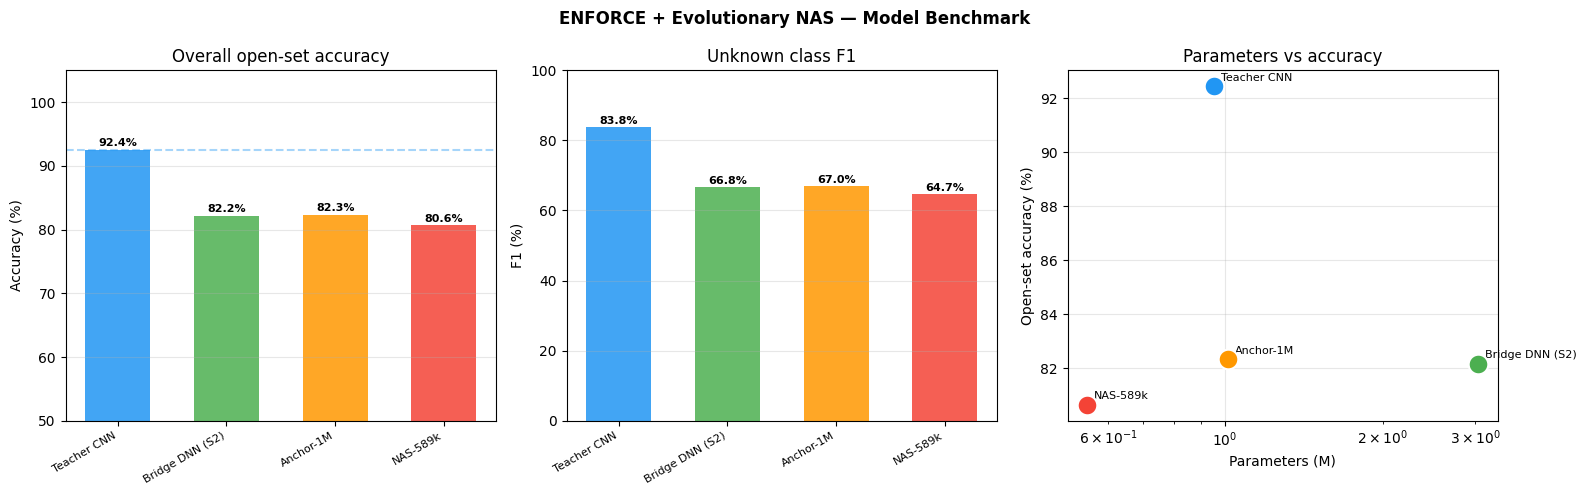

Plot saved → nas_benchmark.png


In [73]:
# ── Efficiency plot ───────────────────────────────────────────────────────────
fig,axes=plt.subplots(1,3,figsize=(16,5))
fig.suptitle("ENFORCE + Evolutionary NAS — Model Benchmark",fontweight="bold")
colors=["#2196F3","#4CAF50","#FF9800","#F44336","#9C27B0","#009688"][:len(all_results)]
x=np.arange(len(all_results)); bw=0.6; labels_p=[r["label"] for r in all_results]

ax=axes[0]
bars=ax.bar(x,[r["acc"]*100 for r in all_results],color=colors,width=bw,alpha=0.85)
for bar,r in zip(bars,all_results):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
            f"{r['acc']*100:.1f}%",ha="center",va="bottom",fontsize=8,fontweight="bold")
ax.set_title("Overall open-set accuracy"); ax.set_ylabel("Accuracy (%)"); ax.set_ylim(50,105)
ax.set_xticks(x); ax.set_xticklabels(labels_p,rotation=30,ha="right",fontsize=8)
ax.axhline(all_results[0]["acc"]*100,color=colors[0],ls="--",alpha=0.4); ax.grid(axis="y",alpha=0.3)

ax=axes[1]
bars=ax.bar(x,[r["unk_f1"]*100 for r in all_results],color=colors,width=bw,alpha=0.85)
for bar,r in zip(bars,all_results):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
            f"{r['unk_f1']*100:.1f}%",ha="center",va="bottom",fontsize=8,fontweight="bold")
ax.set_title("Unknown class F1"); ax.set_ylabel("F1 (%)"); ax.set_ylim(0,100)
ax.set_xticks(x); ax.set_xticklabels(labels_p,rotation=30,ha="right",fontsize=8); ax.grid(axis="y",alpha=0.3)

ax=axes[2]
for i,r in enumerate(all_results):
    ax.scatter(r["params"]/1e6,r["acc"]*100,s=200,color=colors[i],
               edgecolors="white",linewidth=1.5,zorder=5)
    ax.annotate(r["label"],(r["params"]/1e6,r["acc"]*100),
                textcoords="offset points",xytext=(5,4),fontsize=8)
ax.set_title("Parameters vs accuracy"); ax.set_xlabel("Parameters (M)")
ax.set_ylabel("Open-set accuracy (%)"); ax.set_xscale("log"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("nas_benchmark.png",dpi=150,bbox_inches="tight"); plt.show()
print("Plot saved → nas_benchmark.png")


## 14. ONNX export

In [ ]:
import os
dummy=torch.randn(1,CONFIG["flat_dim"]).to(device)
print("Exporting NAS subnets to ONNX...")
for budget,model in sorted(nas_subnets.items()):
    model.eval(); path=f"{CONFIG['nas_subnet_prefix']}_{budget}.onnx"
    try:
        torch.onnx.export(model,dummy,path,
                          input_names=["flat_input"],output_names=["logits"],
                          dynamic_axes={"flat_input":{0:"batch"},"logits":{0:"batch"}},
                          opset_version=13)
        print(f"  NAS-{budget//1000}k → {path}  ({os.path.getsize(path)/1024:.1f} KB)")
    except Exception as ex: print(f"  NAS-{budget//1000}k failed: {ex}")
print("\nDeployment: ONNX → TFLite (onnx-tf) | ONNX → CoreML (coremltools) | ONNX → Syntiant NDP101 SDK")


## 15. Deployment notes

| Target | Model | Params | Notes |
|--------|-------|--------|-------|
| Edge MCU / Syntiant NDP101 | NAS-200k | ≤200k | Flat input only; teacher not needed at runtime |
| Edge SBC (Pi / Jetson) | NAS-350k | ≤350k | Best accuracy/size balance |
| Mobile | NAS-589k | ≤589k | Highest flat-input accuracy |
| Reference | Bridge DNN S2 | ~1M | Structural CNN priors; open-set calibrated |

**Open-set inference:**
```python
logits = model(x_full_flat)                       # [B, 11]
known_probs = softmax(logits[:, known_indices])
max_prob, best = known_probs.max(dim=1)
pred = known_indices[best] if max_prob >= T else unknown_idx
```
